# Análise Long Neck NENO — Ambev Case
### Visualização de dados de demanda, produção, estoque e custos logísticos
Este notebook explora o dataset do case Ambev x Insper, focado no crescimento de cervejas premium em embalagem Long Neck na região Nordeste (NENO).


In [418]:
# Importações e configuração visual padrão
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11
})

# Paleta customizada Ambev
AMBEV_YELLOW = '#FFB800'
AMBEV_DARK = '#1A1A1A'
AMBEV_BLUE = '#4169E1'
AMBEV_RED = '#C0392B'
AMBEV_GREEN = '#27AE60'


## 1. Carregamento dos Dados
Leitura de todas as abas do arquivo Excel convertido (.xlsx).

In [419]:
# Carrega todas as abas relevantes do arquivo
file_path = '/Users/gustavopacheco/Downloads/PS JR/Analise_LongNeck_WSNP_-_Sem_repostas.xlsx'

cenario_br = pd.read_excel(file_path, sheet_name='Cenário atual BR', header=None, engine='calamine')
custos = pd.read_excel(file_path, sheet_name='Custos de transferência', header=None, engine='calamine')
producao_pcp = pd.read_excel(file_path, sheet_name='Produção PCP', header=None, engine='calamine')
transf_prog = pd.read_excel(file_path, sheet_name='Transferências Programadas', header=None, engine='calamine')
cenario_div = pd.read_excel(file_path, sheet_name='Cenário Divulgado', header=None, engine='calamine')
cenario_novo = pd.read_excel(file_path, sheet_name='Cenário com Nova Demanda', header=None, engine='calamine')

print("Abas carregadas com sucesso!")
for name, df in [('Cenário BR', cenario_br), ('Custos', custos), 
                  ('Produção PCP', producao_pcp), ('Transf. Prog.', transf_prog),
                  ('Cenário Divulgado', cenario_div), ('Cenário Nova Demanda', cenario_novo)]:
    print(f"  {name}: {df.shape[0]} linhas x {df.shape[1]} colunas")

Abas carregadas com sucesso!
  Cenário BR: 25 linhas x 24 colunas
  Custos: 23 linhas x 5 colunas
  Produção PCP: 16 linhas x 10 colunas
  Transf. Prog.: 8 linhas x 11 colunas
  Cenário Divulgado: 49 linhas x 48 colunas
  Cenário Nova Demanda: 49 linhas x 48 colunas


## 2. Demanda por Região — Cenário Brasil (Janeiro)
Distribuição da demanda total de Long Neck entre as regionais do Brasil, destacando o peso do NENO.


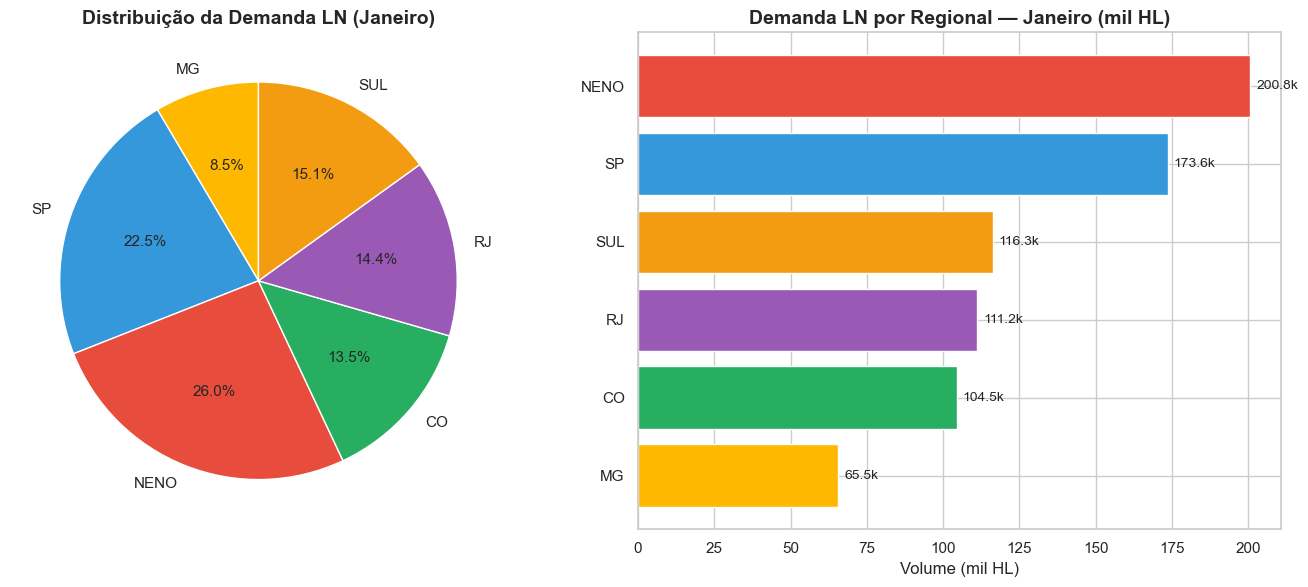

In [420]:
# Cenário atual BR — Demanda Janeiro (lido da aba 'Cenário atual BR')
regioes = ['MG', 'SP', 'NENO', 'CO', 'RJ', 'SUL']
demanda_jan = [
    cenario_br.iloc[5, 3],   # MG
    cenario_br.iloc[6, 3],   # SP
    cenario_br.iloc[7, 3],   # NENO
    cenario_br.iloc[8, 3],   # CO
    cenario_br.iloc[9, 3],   # RJ
    cenario_br.iloc[10, 3],  # SUL
]

colors = [AMBEV_YELLOW, '#3498DB', '#E74C3C', AMBEV_GREEN, '#9B59B6', '#F39C12']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

wedges, texts, autotexts = ax1.pie(demanda_jan, labels=regioes, autopct='%1.1f%%',
                                     colors=colors, startangle=90, textprops={'fontsize': 11})
ax1.set_title('Distribuição da Demanda LN (Janeiro)', fontsize=14, fontweight='bold')

sorted_idx = np.argsort(demanda_jan)
ax2.barh([regioes[i] for i in sorted_idx], [demanda_jan[i]/1000 for i in sorted_idx],
         color=[colors[i] for i in sorted_idx], edgecolor='white')
ax2.set_xlabel('Volume (mil HL)')
ax2.set_title('Demanda LN por Regional — Janeiro (mil HL)', fontsize=14, fontweight='bold')
for i, idx in enumerate(sorted_idx):
    ax2.text(demanda_jan[idx]/1000 + 2, i, f'{demanda_jan[idx]/1000:.1f}k', va='center', fontsize=10)

plt.tight_layout()
plt.show()


## 3. Plano de Produção PCP — Fevereiro 2026
Alocação da produção por SKU nas duas linhas do Nordeste ao longo das 4 semanas de fevereiro.


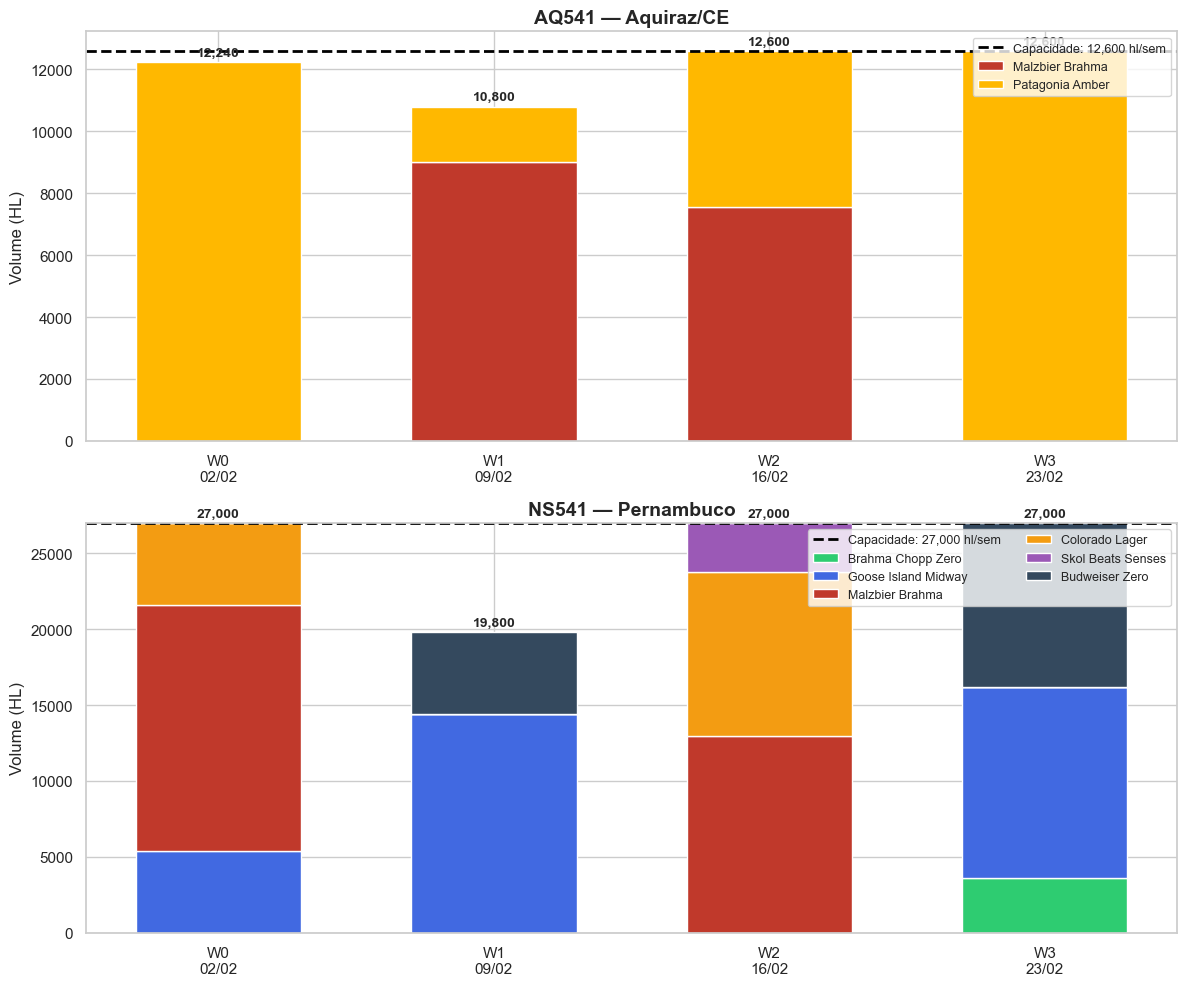

In [421]:
# Produção PCP — lida da aba 'Produção PCP'
semanas = ['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02']

# AQ541 (Aquiraz/CE) — linhas 2-4
aq_malzbier  = list(producao_pcp.iloc[2, 6:10])
aq_patagonia = list(producao_pcp.iloc[3, 6:10])
aq_cap = producao_pcp.iloc[2, 3]

# NS541 (Pernambuco) — linhas 9-14
ns_brahma_zero = list(producao_pcp.iloc[9,  6:10])
ns_goose       = list(producao_pcp.iloc[10, 6:10])
ns_malzbier    = list(producao_pcp.iloc[11, 6:10])
ns_colorado    = list(producao_pcp.iloc[12, 6:10])
ns_skol        = list(producao_pcp.iloc[13, 6:10])
ns_bud_zero    = list(producao_pcp.iloc[14, 6:10])
ns_cap = producao_pcp.iloc[9, 3]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
x = np.arange(4)
w = 0.6

ax1.bar(x, aq_malzbier, w, label='Malzbier Brahma', color=AMBEV_RED)
ax1.bar(x, aq_patagonia, w, bottom=aq_malzbier, label='Patagonia Amber', color=AMBEV_YELLOW)
ax1.axhline(y=aq_cap, color='black', linestyle='--', linewidth=2, label=f'Capacidade: {aq_cap:,.0f} hl/sem')
ax1.set_xticks(x); ax1.set_xticklabels(semanas)
ax1.set_ylabel('Volume (HL)')
ax1.set_title('AQ541 — Aquiraz/CE', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
for i in range(4):
    total = aq_malzbier[i] + aq_patagonia[i]
    ax1.text(i, total + 200, f'{total:,.0f}', ha='center', fontweight='bold', fontsize=10)

b1 = ns_brahma_zero
b2 = [a+b for a,b in zip(b1, ns_goose)]
b3 = [a+b for a,b in zip(b2, ns_malzbier)]
b4 = [a+b for a,b in zip(b3, ns_colorado)]
b5 = [a+b for a,b in zip(b4, ns_skol)]
ax2.bar(x, ns_brahma_zero, w, label='Brahma Chopp Zero',    color='#2ECC71')
ax2.bar(x, ns_goose,       w, bottom=b1, label='Goose Island Midway', color=AMBEV_BLUE)
ax2.bar(x, ns_malzbier,    w, bottom=b2, label='Malzbier Brahma',     color=AMBEV_RED)
ax2.bar(x, ns_colorado,    w, bottom=b3, label='Colorado Lager',      color='#F39C12')
ax2.bar(x, ns_skol,        w, bottom=b4, label='Skol Beats Senses',   color='#9B59B6')
ax2.bar(x, ns_bud_zero,    w, bottom=b5, label='Budweiser Zero',      color='#34495E')
ax2.axhline(y=ns_cap, color='black', linestyle='--', linewidth=2, label=f'Capacidade: {ns_cap:,.0f} hl/sem')
ax2.set_xticks(x); ax2.set_xticklabels(semanas)
ax2.set_ylabel('Volume (HL)')
ax2.set_title('NS541 — Pernambuco', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9, ncol=2)
for i in range(4):
    total = ns_brahma_zero[i]+ns_goose[i]+ns_malzbier[i]+ns_colorado[i]+ns_skol[i]+ns_bud_zero[i]
    ax2.text(i, total + 400, f'{total:,.0f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


## 4. Custos de Transferência e Produção
Comparação entre custo de transferência (SP → NE via cabotagem), MACO e custo de produção por SKU.


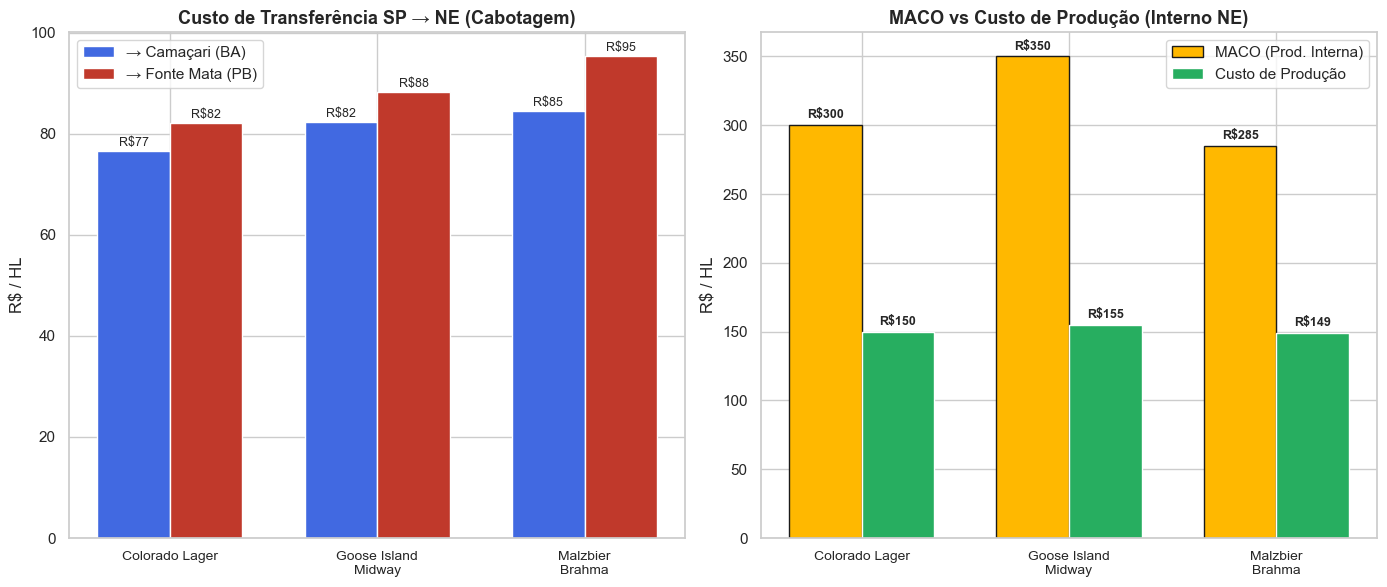

In [422]:
# Custos — lidos da aba 'Custos de transferência'
skus_short = ['Colorado Lager', 'Goose Island\nMidway', 'Malzbier\nBrahma']

transf_camacari  = [custos.iloc[3, 4], custos.iloc[5, 4], custos.iloc[6, 4]]  # → Camaçari
transf_fonte_mata = [custos.iloc[4, 4], custos.iloc[7, 4], custos.iloc[8, 4]]  # → Fonte Mata
maco      = [custos.iloc[13, 4], custos.iloc[14, 4], custos.iloc[15, 4]]
custo_prod = [custos.iloc[20, 4], custos.iloc[21, 4], custos.iloc[22, 4]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
x = np.arange(3)
w = 0.35

ax1.bar(x - w/2, transf_camacari,  w, label='→ Camaçari (BA)', color=AMBEV_BLUE)
ax1.bar(x + w/2, transf_fonte_mata, w, label='→ Fonte Mata (PB)', color=AMBEV_RED)
ax1.set_xticks(x); ax1.set_xticklabels(skus_short, fontsize=10)
ax1.set_ylabel('R$ / HL')
ax1.set_title('Custo de Transferência SP → NE (Cabotagem)', fontsize=13, fontweight='bold')
ax1.legend()
for i in range(3):
    ax1.text(i - w/2, transf_camacari[i]  + 1, f'R${transf_camacari[i]:.0f}',  ha='center', fontsize=9)
    ax1.text(i + w/2, transf_fonte_mata[i] + 1, f'R${transf_fonte_mata[i]:.0f}', ha='center', fontsize=9)

ax2.bar(x - w/2, maco,       w, label='MACO (Prod. Interna)', color=AMBEV_YELLOW, edgecolor=AMBEV_DARK)
ax2.bar(x + w/2, custo_prod, w, label='Custo de Produção',    color=AMBEV_GREEN)
ax2.set_xticks(x); ax2.set_xticklabels(skus_short, fontsize=10)
ax2.set_ylabel('R$ / HL')
ax2.set_title('MACO vs Custo de Produção (Interno NE)', fontsize=13, fontweight='bold')
ax2.legend()
for i in range(3):
    ax2.text(i - w/2, maco[i]       + 5, f'R${maco[i]:.0f}',       ha='center', fontsize=9, fontweight='bold')
    ax2.text(i + w/2, custo_prod[i] + 5, f'R${custo_prod[i]:.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## 5. Transferências Programadas — Goose Island (SP → NE)
Volumes semanais de transferência programados por destino (heatmap) e composição do abastecimento total NENO: como a cabotagem se compara com WSNP, transferência interna e rodoviária.

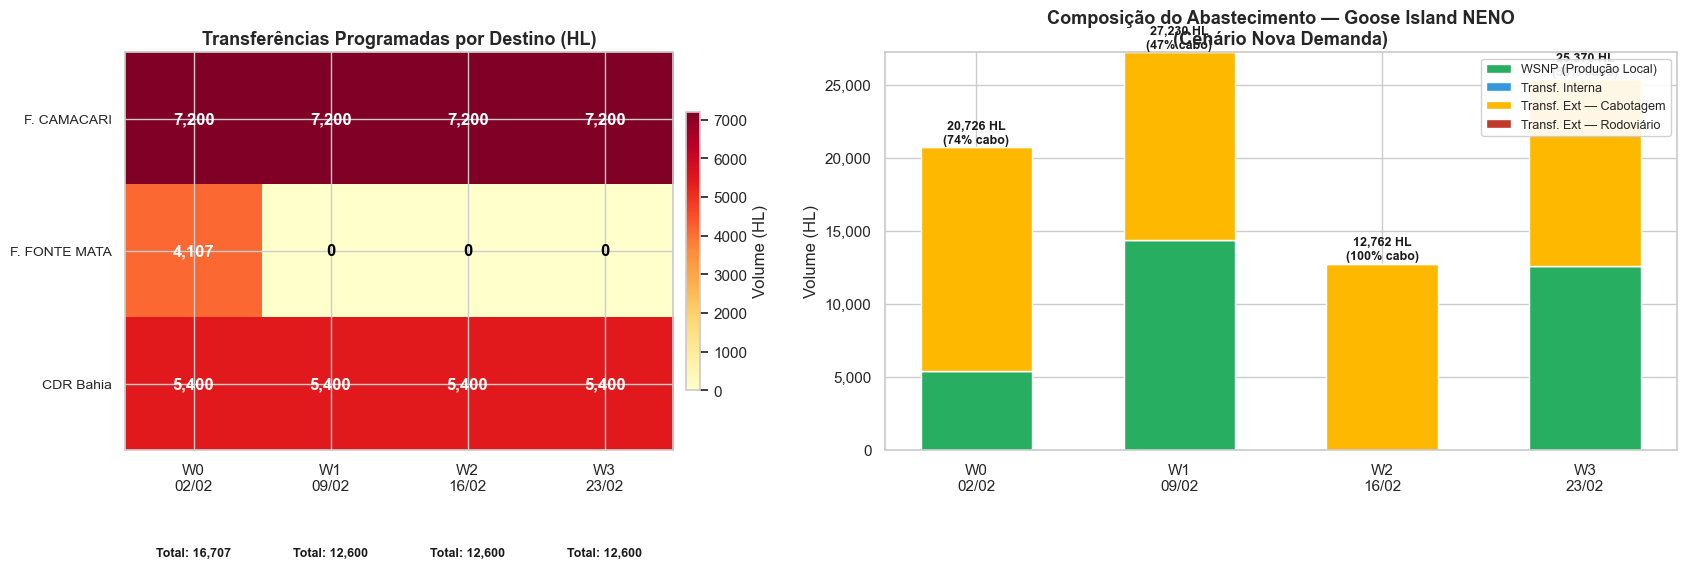

In [423]:
# Transferências Programadas — Goose Island: Heatmap + Composição do Abastecimento
semanas_tr = ['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02']

# ========== DADOS ==========
# Heatmap: transferências por destino (aba Transferências Programadas)
destinos = list(transf_prog.iloc[3:6, 3])
volumes = transf_prog.iloc[3:6, 7:11].fillna(0).values.astype(float)

# Composição abastecimento: Goose Island TOTAL (row 17) — Cenário Nova Demanda
goose_total = 17
wsnp_cols   = [5, 18, 29, 40]
tint_cols   = [9, 20, 31, 42]
cabo_cols   = [10, 21, 32, 43]
rodo_cols   = [11, 22, 33, 44]

wsnp_vals = [max(cenario_novo.iloc[goose_total, c], 0) for c in wsnp_cols]
tint_vals = [max(cenario_novo.iloc[goose_total, c], 0) for c in tint_cols]
cabo_vals = [max(cenario_novo.iloc[goose_total, c], 0) for c in cabo_cols]
rodo_vals = [max(cenario_novo.iloc[goose_total, c], 0) for c in rodo_cols]

# ========== GRÁFICOS ==========
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6),
                                 gridspec_kw={'width_ratios': [1, 1.2]})

# --- Heatmap (esquerda) ---
im = ax1.imshow(volumes, cmap='YlOrRd', aspect='auto')
ax1.set_xticks(range(4)); ax1.set_xticklabels(semanas_tr)
ax1.set_yticks(range(3)); ax1.set_yticklabels(destinos, fontsize=10)
for i in range(3):
    for j in range(4):
        color = 'white' if volumes[i, j] > 4000 else 'black'
        ax1.text(j, i, f'{volumes[i,j]:,.0f}', ha='center', va='center',
                 fontsize=12, fontweight='bold', color=color)
totais_hm = volumes.sum(axis=0)
for j in range(4):
    ax1.text(j, 3.3, f'Total: {totais_hm[j]:,.0f}', ha='center', fontsize=9,
             fontweight='bold', color=AMBEV_DARK)
ax1.set_title('Transferências Programadas por Destino (HL)', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax1, shrink=0.7, pad=0.02).set_label('Volume (HL)')

# --- Barras empilhadas: composição do abastecimento (direita) ---
x = np.arange(4)
w = 0.55

b_wsnp = ax2.bar(x, wsnp_vals, w, label='WSNP (Produção Local)', color=AMBEV_GREEN, edgecolor='white')
b_tint = ax2.bar(x, tint_vals, w, bottom=wsnp_vals, label='Transf. Interna', color='#3498DB', edgecolor='white')
bot2 = [a+b for a,b in zip(wsnp_vals, tint_vals)]
b_cabo = ax2.bar(x, cabo_vals, w, bottom=bot2, label='Transf. Ext — Cabotagem', color=AMBEV_YELLOW, edgecolor='white')
bot3 = [a+b for a,b in zip(bot2, cabo_vals)]
b_rodo = ax2.bar(x, rodo_vals, w, bottom=bot3, label='Transf. Ext — Rodoviário', color=AMBEV_RED, edgecolor='white')

# Labels de % cabo sobre total
for i in range(4):
    total_i = wsnp_vals[i] + tint_vals[i] + cabo_vals[i] + rodo_vals[i]
    if total_i > 0:
        pct_cabo = cabo_vals[i] / total_i * 100
        ax2.text(i, total_i + 300, f'{total_i:,.0f} HL\n({pct_cabo:.0f}% cabo)',
                 ha='center', fontsize=9, fontweight='bold', color=AMBEV_DARK)

ax2.set_xticks(x); ax2.set_xticklabels(semanas_tr)
ax2.set_ylabel('Volume (HL)')
ax2.set_title('Composição do Abastecimento — Goose Island NENO\n(Cenário Nova Demanda)', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

## 6. Utilização da Capacidade Produtiva — Fevereiro 2026
Percentual de ocupação das linhas AQ541 e NS541, calculado a partir do PCP.


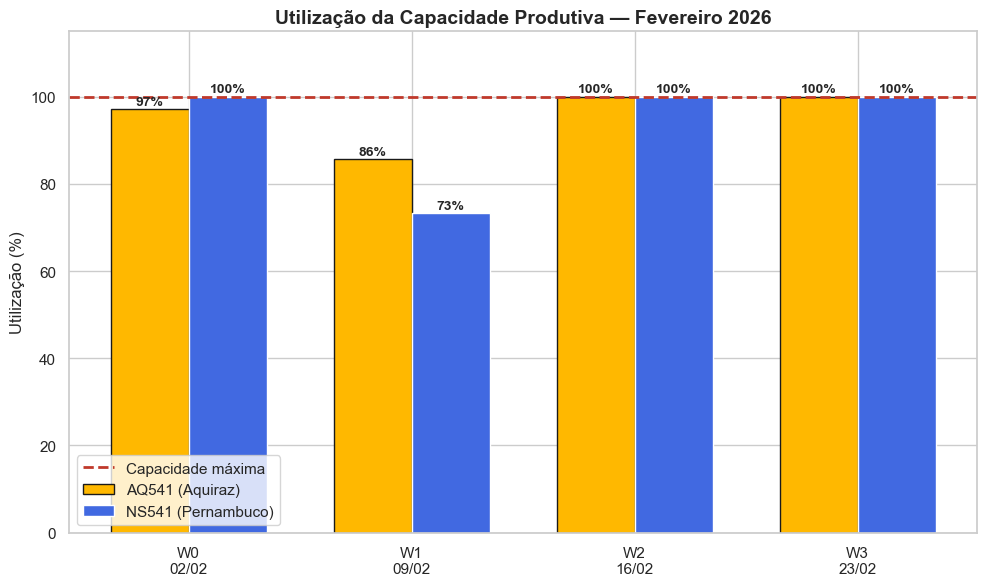

In [424]:
# Utilização de capacidade — calculada a partir da aba 'Produção PCP'
cap_aq = producao_pcp.iloc[2, 3]
cap_ns = producao_pcp.iloc[9, 3]
prod_aq = list(producao_pcp.iloc[5, 6:10])
prod_ns = list(producao_pcp.iloc[15, 6:10])

util_aq = [p / cap_aq * 100 for p in prod_aq]
util_ns = [p / cap_ns * 100 for p in prod_ns]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(4)
w = 0.35
bars1 = ax.bar(x - w/2, util_aq, w, label='AQ541 (Aquiraz)',    color=AMBEV_YELLOW, edgecolor=AMBEV_DARK)
bars2 = ax.bar(x + w/2, util_ns, w, label='NS541 (Pernambuco)', color=AMBEV_BLUE)
ax.axhline(y=100, color=AMBEV_RED, linestyle='--', linewidth=2, label='Capacidade máxima')
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}%', ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02'])
ax.set_ylabel('Utilização (%)')
ax.set_ylim(0, 115)
ax.set_title('Utilização da Capacidade Produtiva — Fevereiro 2026', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


## 7. Mix de Produção por Fábrica e Semana
Proporção das cervejas produzidas em cada fábrica (AQ541 — Aquiraz/CE e NS541 — Pernambuco) ao longo das 4 semanas de fevereiro.

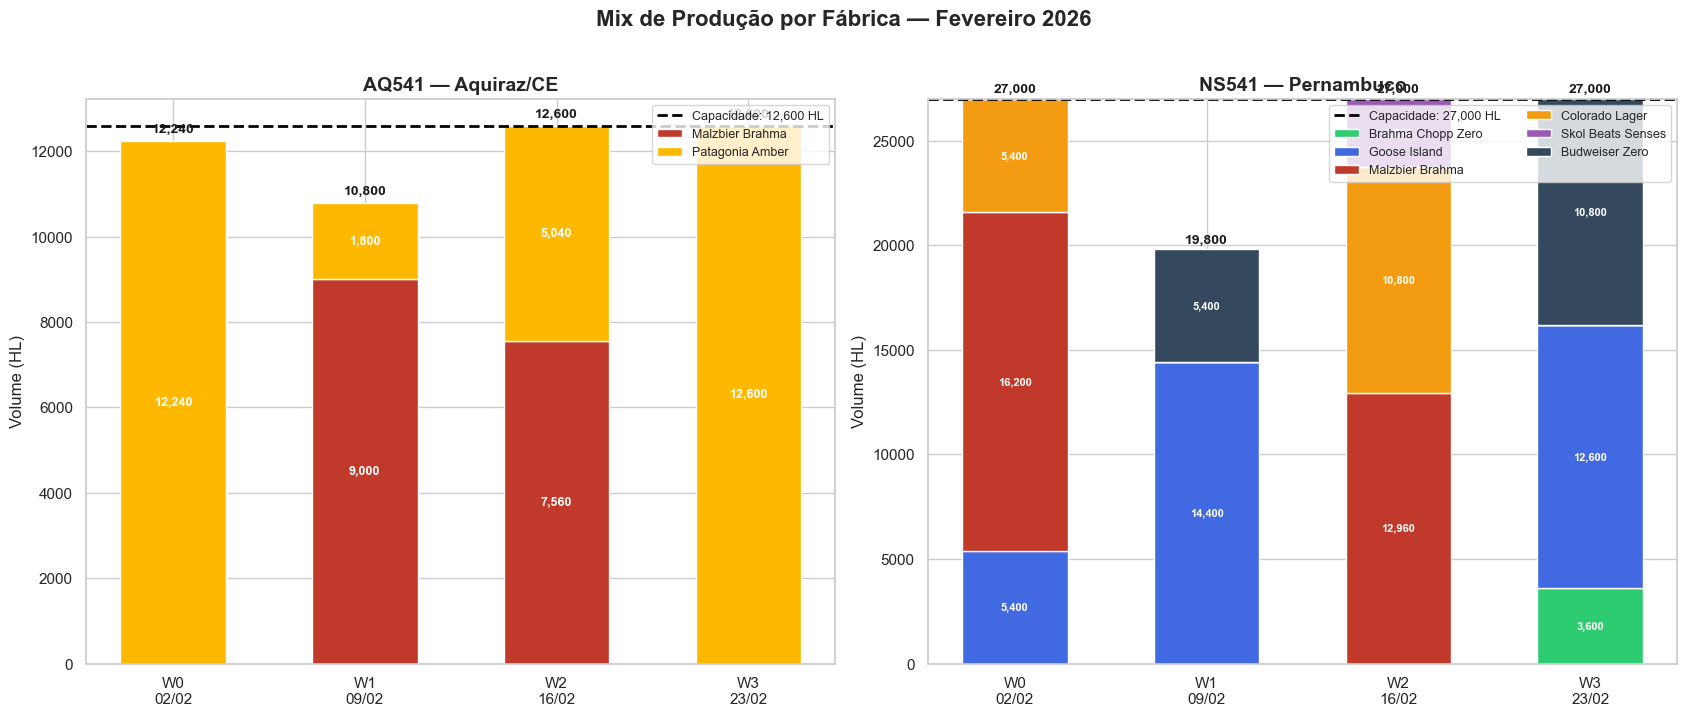

In [425]:
# Mix de Produção por Fábrica — AQ541 vs NS541, por semana
semanas_label = ['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02']

# AQ541 — Aquiraz/CE (rows 2-3, cols 6-9)
aq_skus = {
    'Malzbier Brahma':  list(producao_pcp.iloc[2, 6:10].astype(float)),
    'Patagonia Amber':  list(producao_pcp.iloc[3, 6:10].astype(float)),
}

# NS541 — Pernambuco (rows 9-14, cols 6-9)
ns_skus = {
    'Brahma Chopp Zero':  list(producao_pcp.iloc[9,  6:10].astype(float)),
    'Goose Island':       list(producao_pcp.iloc[10, 6:10].astype(float)),
    'Malzbier Brahma':    list(producao_pcp.iloc[11, 6:10].astype(float)),
    'Colorado Lager':     list(producao_pcp.iloc[12, 6:10].astype(float)),
    'Skol Beats Senses':  list(producao_pcp.iloc[13, 6:10].astype(float)),
    'Budweiser Zero':     list(producao_pcp.iloc[14, 6:10].astype(float)),
}

# Cores consistentes para cada SKU
sku_colors = {
    'Malzbier Brahma':   AMBEV_RED,
    'Patagonia Amber':   AMBEV_YELLOW,
    'Brahma Chopp Zero': '#2ECC71',
    'Goose Island':      AMBEV_BLUE,
    'Colorado Lager':    '#F39C12',
    'Skol Beats Senses': '#9B59B6',
    'Budweiser Zero':    '#34495E',
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 7))
x = np.arange(4)
w = 0.55

# --- AQ541 (esquerda) ---
bottom_aq = np.zeros(4)
for sku, vals in aq_skus.items():
    ax1.bar(x, vals, w, bottom=bottom_aq, label=sku, color=sku_colors[sku], edgecolor='white')
    # Label dentro da barra
    for i in range(4):
        if vals[i] > 0:
            mid = bottom_aq[i] + vals[i] / 2
            ax1.text(i, mid, f'{vals[i]:,.0f}', ha='center', va='center',
                     fontsize=9, fontweight='bold', color='white')
    bottom_aq += np.array(vals)

# Total no topo
for i in range(4):
    ax1.text(i, bottom_aq[i] + 200, f'{bottom_aq[i]:,.0f}', ha='center',
             fontsize=10, fontweight='bold', color=AMBEV_DARK)

cap_aq = producao_pcp.iloc[2, 3]
ax1.axhline(y=cap_aq, color='black', linestyle='--', linewidth=2,
            label=f'Capacidade: {cap_aq:,.0f} HL')
ax1.set_xticks(x); ax1.set_xticklabels(semanas_label)
ax1.set_ylabel('Volume (HL)', fontsize=12)
ax1.set_title('AQ541 — Aquiraz/CE', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)

# --- NS541 (direita) ---
bottom_ns = np.zeros(4)
for sku, vals in ns_skus.items():
    ax2.bar(x, vals, w, bottom=bottom_ns, label=sku, color=sku_colors[sku], edgecolor='white')
    for i in range(4):
        if vals[i] > 0:
            mid = bottom_ns[i] + vals[i] / 2
            ax2.text(i, mid, f'{vals[i]:,.0f}', ha='center', va='center',
                     fontsize=8, fontweight='bold', color='white')
    bottom_ns += np.array(vals)

for i in range(4):
    ax2.text(i, bottom_ns[i] + 300, f'{bottom_ns[i]:,.0f}', ha='center',
             fontsize=10, fontweight='bold', color=AMBEV_DARK)

cap_ns = producao_pcp.iloc[9, 3]
ax2.axhline(y=cap_ns, color='black', linestyle='--', linewidth=2,
            label=f'Capacidade: {cap_ns:,.0f} HL')
ax2.set_xticks(x); ax2.set_xticklabels(semanas_label)
ax2.set_ylabel('Volume (HL)', fontsize=12)
ax2.set_title('NS541 — Pernambuco', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9, ncol=2)

fig.suptitle('Mix de Produção por Fábrica — Fevereiro 2026', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Demanda Semanal — Malzbier Brahma: Divulgado vs Nova Demanda
Evolução da demanda total NENO de Malzbier ao longo das 4 semanas de fevereiro, comparando os dois cenários.

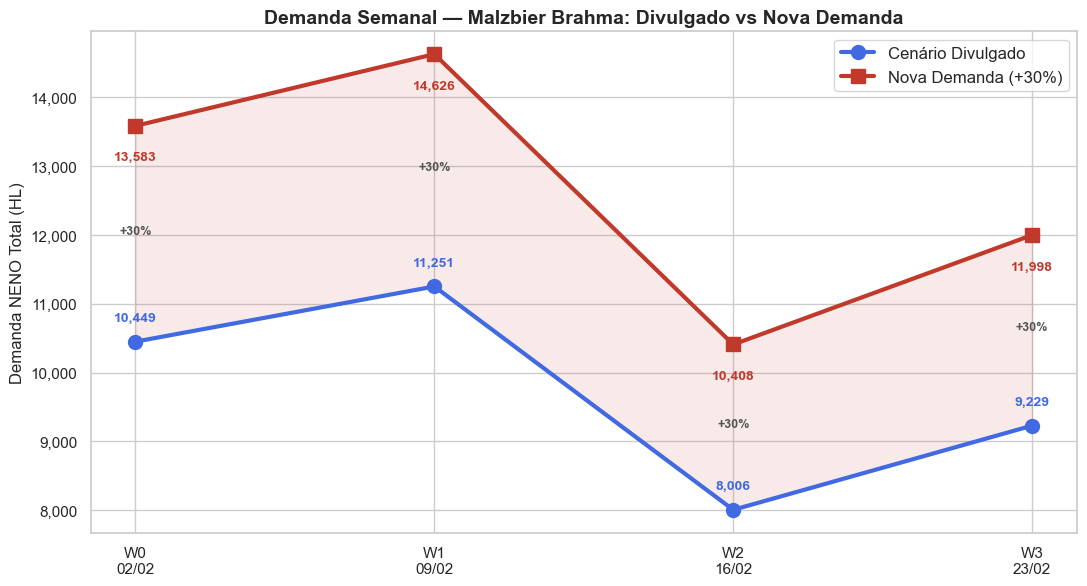

In [426]:
# Demanda Semanal Malzbier Brahma — Divulgado vs Nova Demanda (TOTAL NENO)
dem_cols = [3, 16, 27, 38]
semanas_label = ['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02']
malz_total = 25  # linha TOTAL do bloco Malzbier

dem_div  = [cenario_div.iloc[malz_total,  c] for c in dem_cols]
dem_novo = [cenario_novo.iloc[malz_total, c] for c in dem_cols]

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(semanas_label, dem_div,  'o-', linewidth=3, markersize=10, color=AMBEV_BLUE,
        label='Cenário Divulgado')
ax.plot(semanas_label, dem_novo, 's-', linewidth=3, markersize=10, color=AMBEV_RED,
        label='Nova Demanda (+30%)')

# Área entre as curvas para destacar o delta
ax.fill_between(range(4), dem_div, dem_novo, alpha=0.10, color=AMBEV_RED)

# Labels de valor e delta %
for i in range(4):
    ax.text(i, dem_div[i] + 300, f'{dem_div[i]:,.0f}', ha='center', fontsize=10,
            color=AMBEV_BLUE, fontweight='bold')
    ax.text(i, dem_novo[i] - 500, f'{dem_novo[i]:,.0f}', ha='center', fontsize=10,
            color=AMBEV_RED, fontweight='bold')
    delta = (dem_novo[i] - dem_div[i]) / dem_div[i] * 100
    mid_y = (dem_div[i] + dem_novo[i]) / 2
    ax.annotate(f'+{delta:.0f}%', (i, mid_y), fontsize=9, fontweight='bold',
                color='#555', ha='center')

ax.set_ylabel('Demanda NENO Total (HL)', fontsize=12)
ax.set_title('Demanda Semanal — Malzbier Brahma: Divulgado vs Nova Demanda',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

## 9. Suficiência em Dias (DOI) — Malzbier Brahma: Divulgado vs Nova Demanda
Comparação da suficiência por GEO nos dois cenários ao longo das 4 semanas de fevereiro.

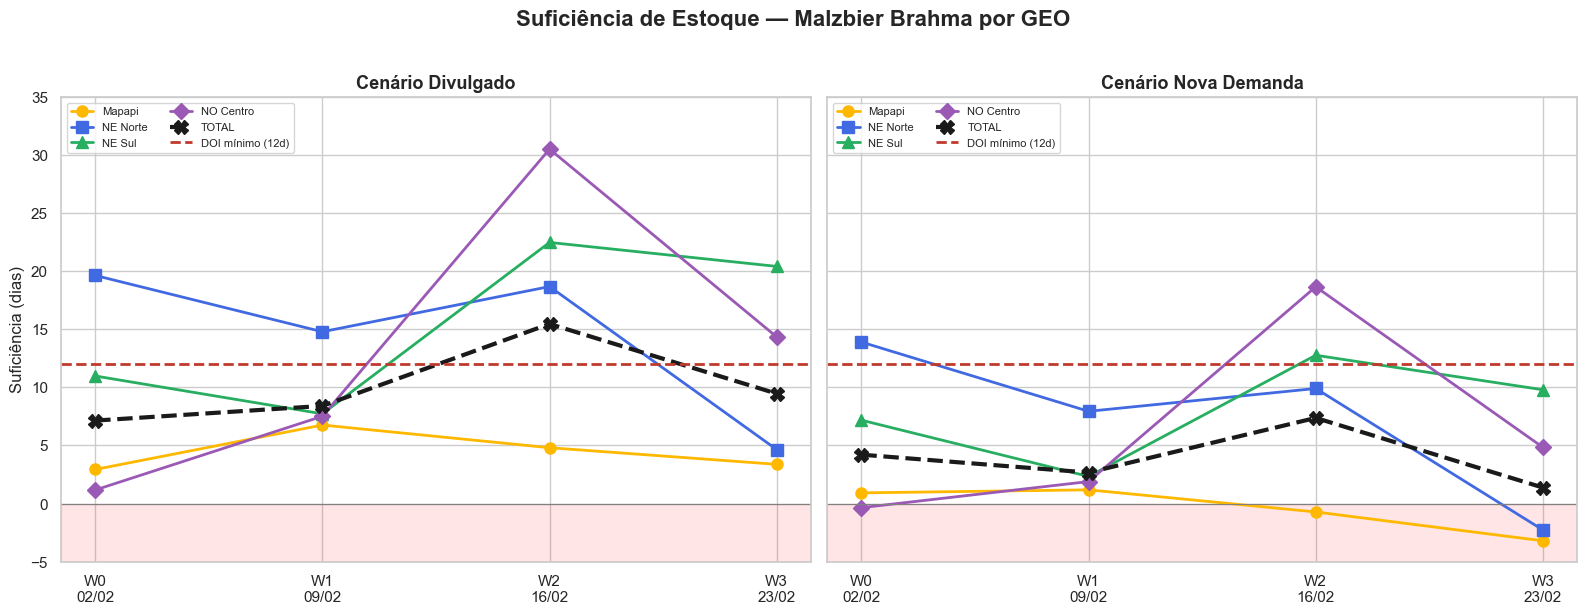

In [427]:
# Suficiência Malzbier — Divulgado vs Nova Demanda, por GEO
suf_cols = [14, 25, 36, 47]
semanas_label = ['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02']
geo_names = ['Mapapi', 'NE Norte', 'NE Sul', 'NO Centro']
geo_rows  = [20, 21, 22, 24]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

markers_list = ['o', 's', '^', 'D']
geo_colors = [AMBEV_YELLOW, AMBEV_BLUE, AMBEV_GREEN, '#9B59B6']

# --- Cenário Divulgado (esquerda) ---
for geo, row, m, c in zip(geo_names, geo_rows, markers_list, geo_colors):
    vals = [cenario_div.iloc[row, col] for col in suf_cols]
    ax1.plot(semanas_label, vals, marker=m, linewidth=2, markersize=8, label=geo, color=c)

total_div = [cenario_div.iloc[25, col] for col in suf_cols]
ax1.plot(semanas_label, total_div, 'X--', linewidth=3, markersize=10, color=AMBEV_DARK, label='TOTAL')
ax1.axhline(y=12, color=AMBEV_RED, linestyle='--', linewidth=2, label='DOI mínimo (12d)')
ax1.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
ax1.axhspan(-5, 0, alpha=0.1, color='red')
ax1.set_ylabel('Suficiência (dias)')
ax1.set_title('Cenário Divulgado', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=8, ncol=2)
ax1.set_ylim(-5, 35)

# --- Cenário Nova Demanda (direita) — mesma estrutura ---
for geo, row, m, c in zip(geo_names, geo_rows, markers_list, geo_colors):
    vals = [cenario_novo.iloc[row, col] for col in suf_cols]
    ax2.plot(semanas_label, vals, marker=m, linewidth=2, markersize=8, label=geo, color=c)

total_novo = [cenario_novo.iloc[25, col] for col in suf_cols]
ax2.plot(semanas_label, total_novo, 'X--', linewidth=3, markersize=10, color=AMBEV_DARK, label='TOTAL')
ax2.axhline(y=12, color=AMBEV_RED, linestyle='--', linewidth=2, label='DOI mínimo (12d)')
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
ax2.axhspan(-5, 0, alpha=0.1, color='red')
ax2.set_title('Cenário Nova Demanda', fontsize=13, fontweight='bold')
ax2.legend(loc='upper left', fontsize=8, ncol=2)

fig.suptitle('Suficiência de Estoque — Malzbier Brahma por GEO', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Suficiência em Dias — 4 Cervejas por GEO (Cenário Nova Demanda)
Cobertura de estoque por GEO ao longo das 4 semanas para Patagonia, Goose Island, Malzbier e Colorado no cenário com nova demanda.

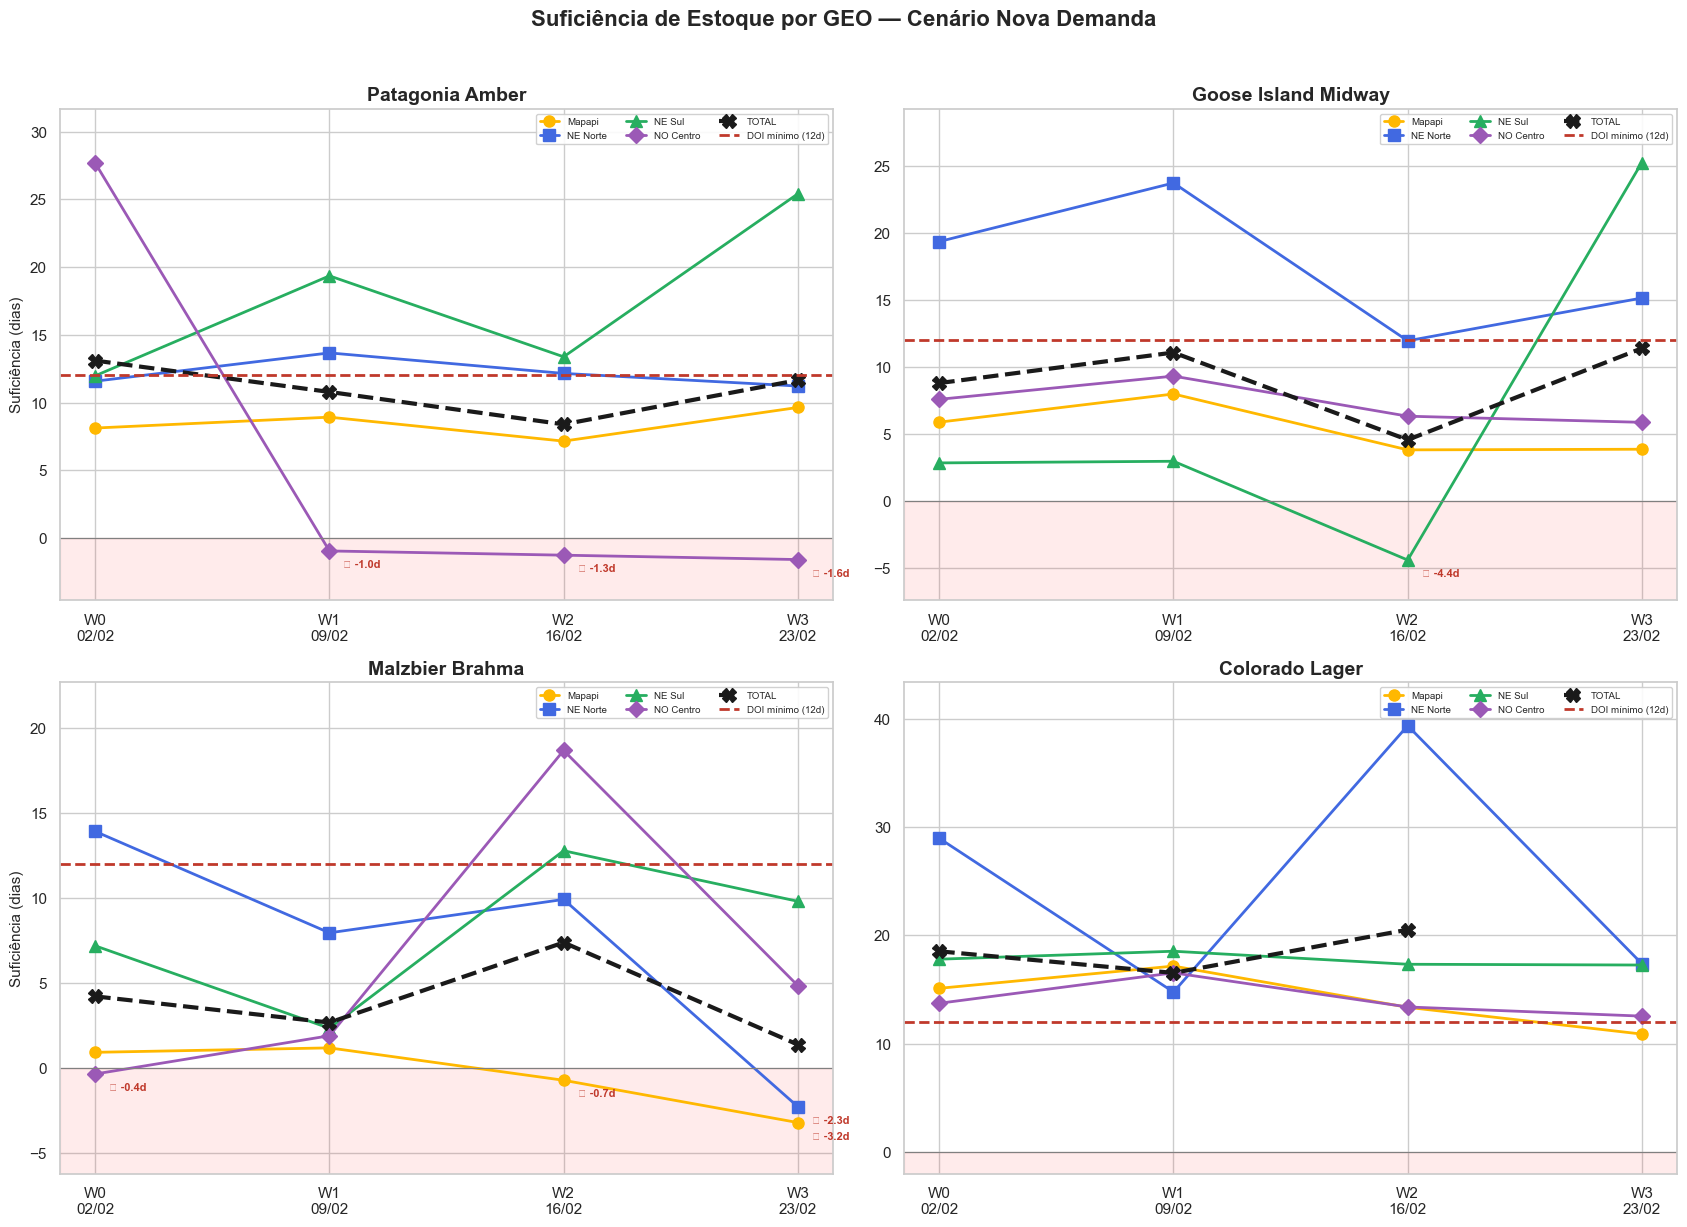

In [428]:
# Suficiência por GEO — 4 cervejas, Cenário Nova Demanda
suf_cols = [14, 25, 36, 47]
semanas_label = ['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02']

cervejas_config = {
    'Patagonia Amber':     {'geo_rows': [4, 5, 6, 8],    'total': 9},
    'Goose Island Midway': {'geo_rows': [12, 13, 14, 16], 'total': 17},
    'Malzbier Brahma':     {'geo_rows': [20, 21, 22, 24], 'total': 25},
    'Colorado Lager':      {'geo_rows': [28, 29, 30, 32], 'total': 33},
}

geo_names  = ['Mapapi', 'NE Norte', 'NE Sul', 'NO Centro']
geo_colors = [AMBEV_YELLOW, AMBEV_BLUE, AMBEV_GREEN, '#9B59B6']
markers_list = ['o', 's', '^', 'D']

fig, axes = plt.subplots(2, 2, figsize=(17, 12))
axes_flat = axes.flatten()

for idx, (cerveja, cfg) in enumerate(cervejas_config.items()):
    ax = axes_flat[idx]
    all_vals = []

    # Linhas por GEO
    for geo, row, m, c in zip(geo_names, cfg['geo_rows'], markers_list, geo_colors):
        vals = [cenario_novo.iloc[row, col] for col in suf_cols]
        ax.plot(semanas_label, vals, marker=m, linewidth=2, markersize=8, label=geo, color=c)
        all_vals.extend(vals)

    # TOTAL — substituir placeholders 99 por NaN
    total_vals = []
    for col in suf_cols:
        v = cenario_novo.iloc[cfg['total'], col]
        total_vals.append(np.nan if v == 99 else v)
    ax.plot(semanas_label, total_vals, 'X--', linewidth=3, markersize=10,
            color=AMBEV_DARK, label='TOTAL')
    all_vals.extend([v for v in total_vals if not np.isnan(v)])

    # Referências
    ax.axhline(y=12, color=AMBEV_RED, linestyle='--', linewidth=2, label='DOI mínimo (12d)')
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)

    # Escala individual por cerveja
    y_min = min(all_vals) - 3
    y_max = max(all_vals) + 4
    if y_min > -2:
        y_min = -2
    ax.set_ylim(y_min, y_max)
    ax.axhspan(y_min, 0, alpha=0.08, color='red')

    ax.set_title(cerveja, fontsize=14, fontweight='bold')
    if idx % 2 == 0:
        ax.set_ylabel('Suficiência (dias)', fontsize=11)
    ax.legend(loc='upper right', fontsize=7, ncol=3, framealpha=0.9)

    # Anotação de ruptura (valores negativos)
    for geo, row, c in zip(geo_names, cfg['geo_rows'], geo_colors):
        for wk, col in enumerate(suf_cols):
            val = cenario_novo.iloc[row, col]
            if val < 0:
                ax.annotate(f'⚠ {val:.1f}d', (wk, val),
                            textcoords='offset points', xytext=(10, -12),
                            fontsize=8, color=AMBEV_RED, fontweight='bold')

fig.suptitle('Suficiência de Estoque por GEO — Cenário Nova Demanda',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 11. Estoque Final e Demanda — Malzbier Brahma por GEO
Evolução do estoque final (linha contínua) e demanda (linha pontilhada) de Malzbier em cada GEO do NENO, comparando Cenário Divulgado e Nova Demanda.

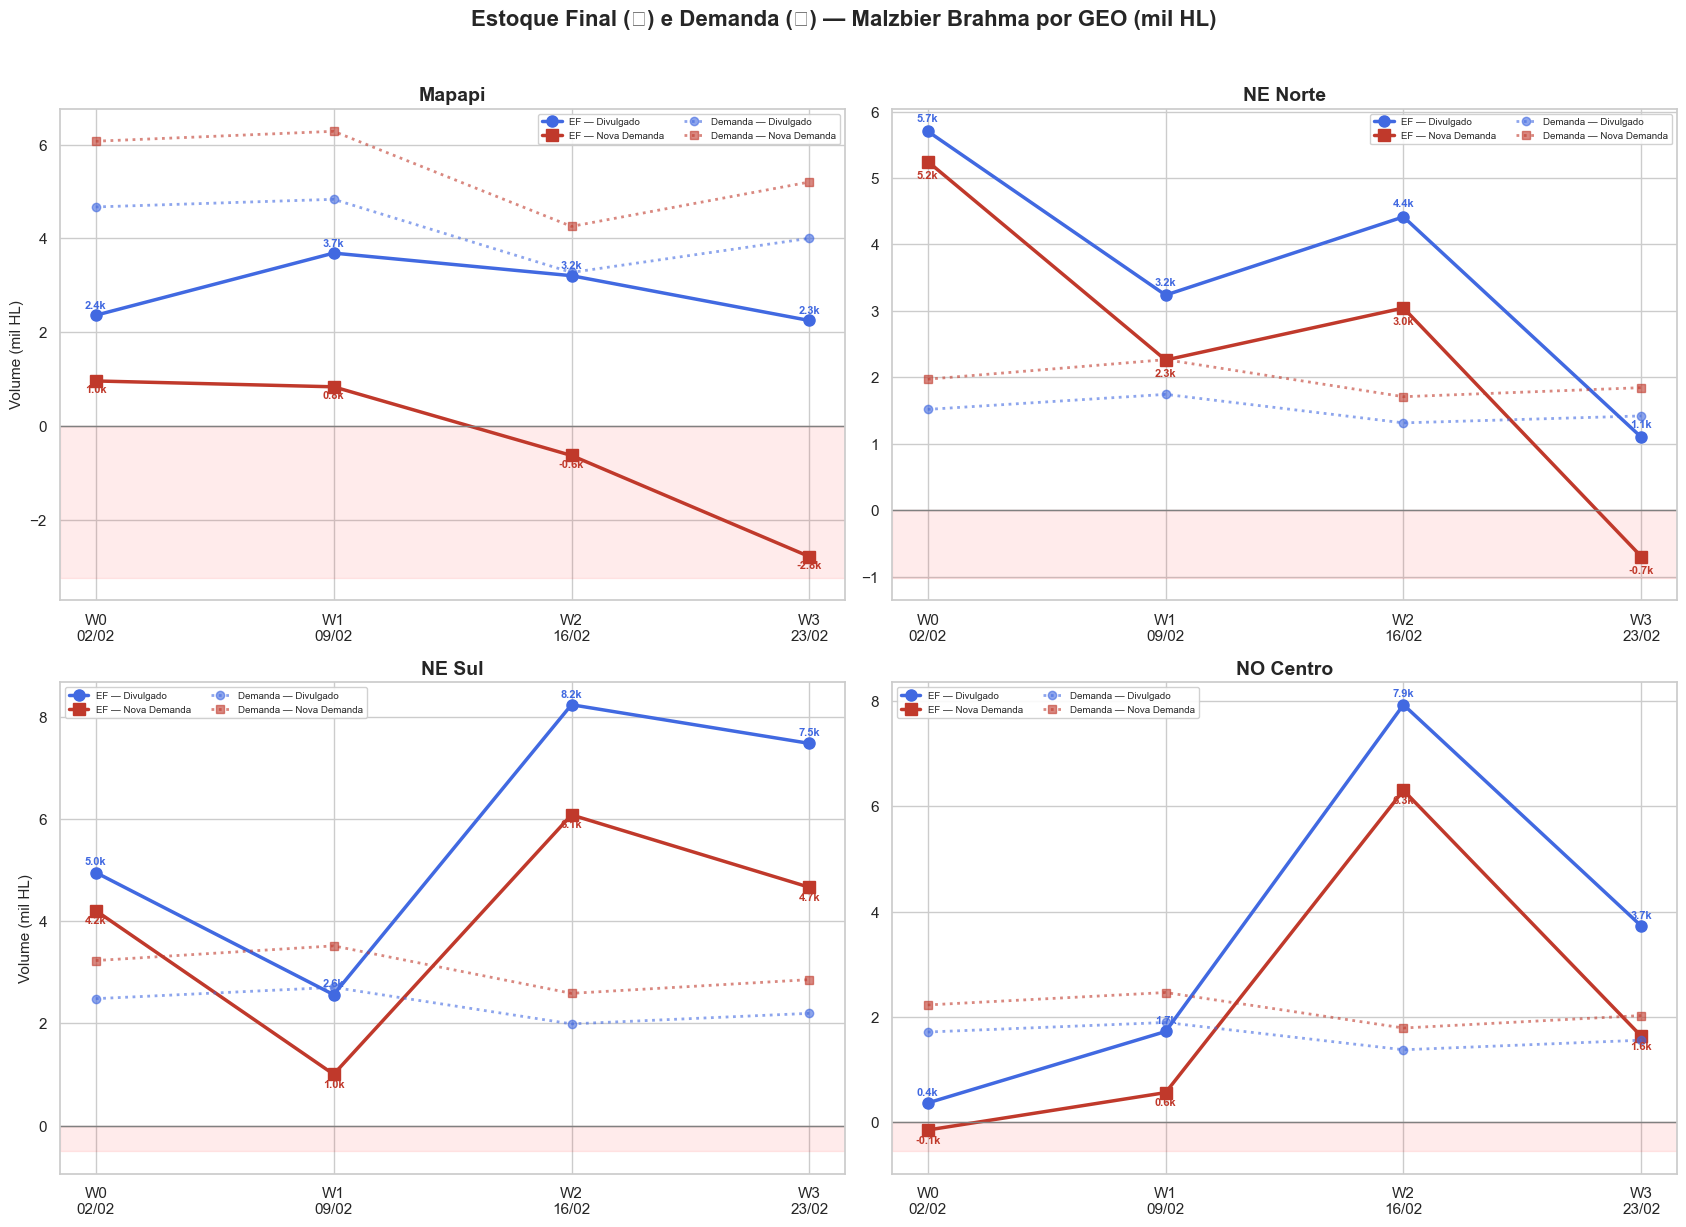

In [429]:
# Estoque Final e Demanda — Malzbier por GEO: Divulgado vs Nova Demanda
ef_cols  = [13, 24, 35, 46]   # EF Semana
dem_cols = [3, 16, 27, 38]    # Demanda
semanas_label = ['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02']

geo_names = ['Mapapi', 'NE Norte', 'NE Sul', 'NO Centro']
geo_rows  = [20, 21, 22, 24]

fig, axes = plt.subplots(2, 2, figsize=(17, 12))
axes_flat = axes.flatten()
x = np.arange(4)

for idx, (geo, row) in enumerate(zip(geo_names, geo_rows)):
    ax = axes_flat[idx]

    # Estoque Final — linhas contínuas
    ef_div  = [cenario_div.iloc[row, c] / 1000 for c in ef_cols]
    ef_novo = [cenario_novo.iloc[row, c] / 1000 for c in ef_cols]
    ax.plot(x, ef_div,  'o-',  linewidth=2.5, markersize=8, color=AMBEV_BLUE,
            label='EF — Divulgado')
    ax.plot(x, ef_novo, 's-',  linewidth=2.5, markersize=8, color=AMBEV_RED,
            label='EF — Nova Demanda')

    # Demanda — linhas pontilhadas
    dem_div  = [cenario_div.iloc[row, c] / 1000 for c in dem_cols]
    dem_novo = [cenario_novo.iloc[row, c] / 1000 for c in dem_cols]
    ax.plot(x, dem_div,  'o:', linewidth=2, markersize=6, color=AMBEV_BLUE, alpha=0.6,
            label='Demanda — Divulgado')
    ax.plot(x, dem_novo, 's:', linewidth=2, markersize=6, color=AMBEV_RED, alpha=0.6,
            label='Demanda — Nova Demanda')

    # Labels de estoque final
    for i in range(4):
        ax.text(i, ef_div[i] + 0.15, f'{ef_div[i]:.1f}k', ha='center', fontsize=8,
                color=AMBEV_BLUE, fontweight='bold')
        offset = -0.25 if ef_novo[i] < ef_div[i] else 0.15
        ax.text(i, ef_novo[i] + offset, f'{ef_novo[i]:.1f}k', ha='center', fontsize=8,
                color=AMBEV_RED, fontweight='bold')

    # Zona de ruptura
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=1)
    y_min = ax.get_ylim()[0]
    ax.axhspan(min(y_min, -0.5), 0, alpha=0.08, color='red')

    ax.set_xticks(x)
    ax.set_xticklabels(semanas_label)
    ax.set_title(geo, fontsize=14, fontweight='bold')
    if idx % 2 == 0:
        ax.set_ylabel('Volume (mil HL)', fontsize=11)
    ax.legend(loc='best', fontsize=7, ncol=2, framealpha=0.9)

fig.suptitle('Estoque Final (━) e Demanda (┈) — Malzbier Brahma por GEO (mil HL)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 12. Suficiência Malzbier Brahma — Divulgado vs Nova Demanda por GEO e Semana
Comparação da suficiência em dias entre os dois cenários para cada GEO ao longo das 4 semanas, com painel final consolidando a suficiência W3 de todas as regiões.

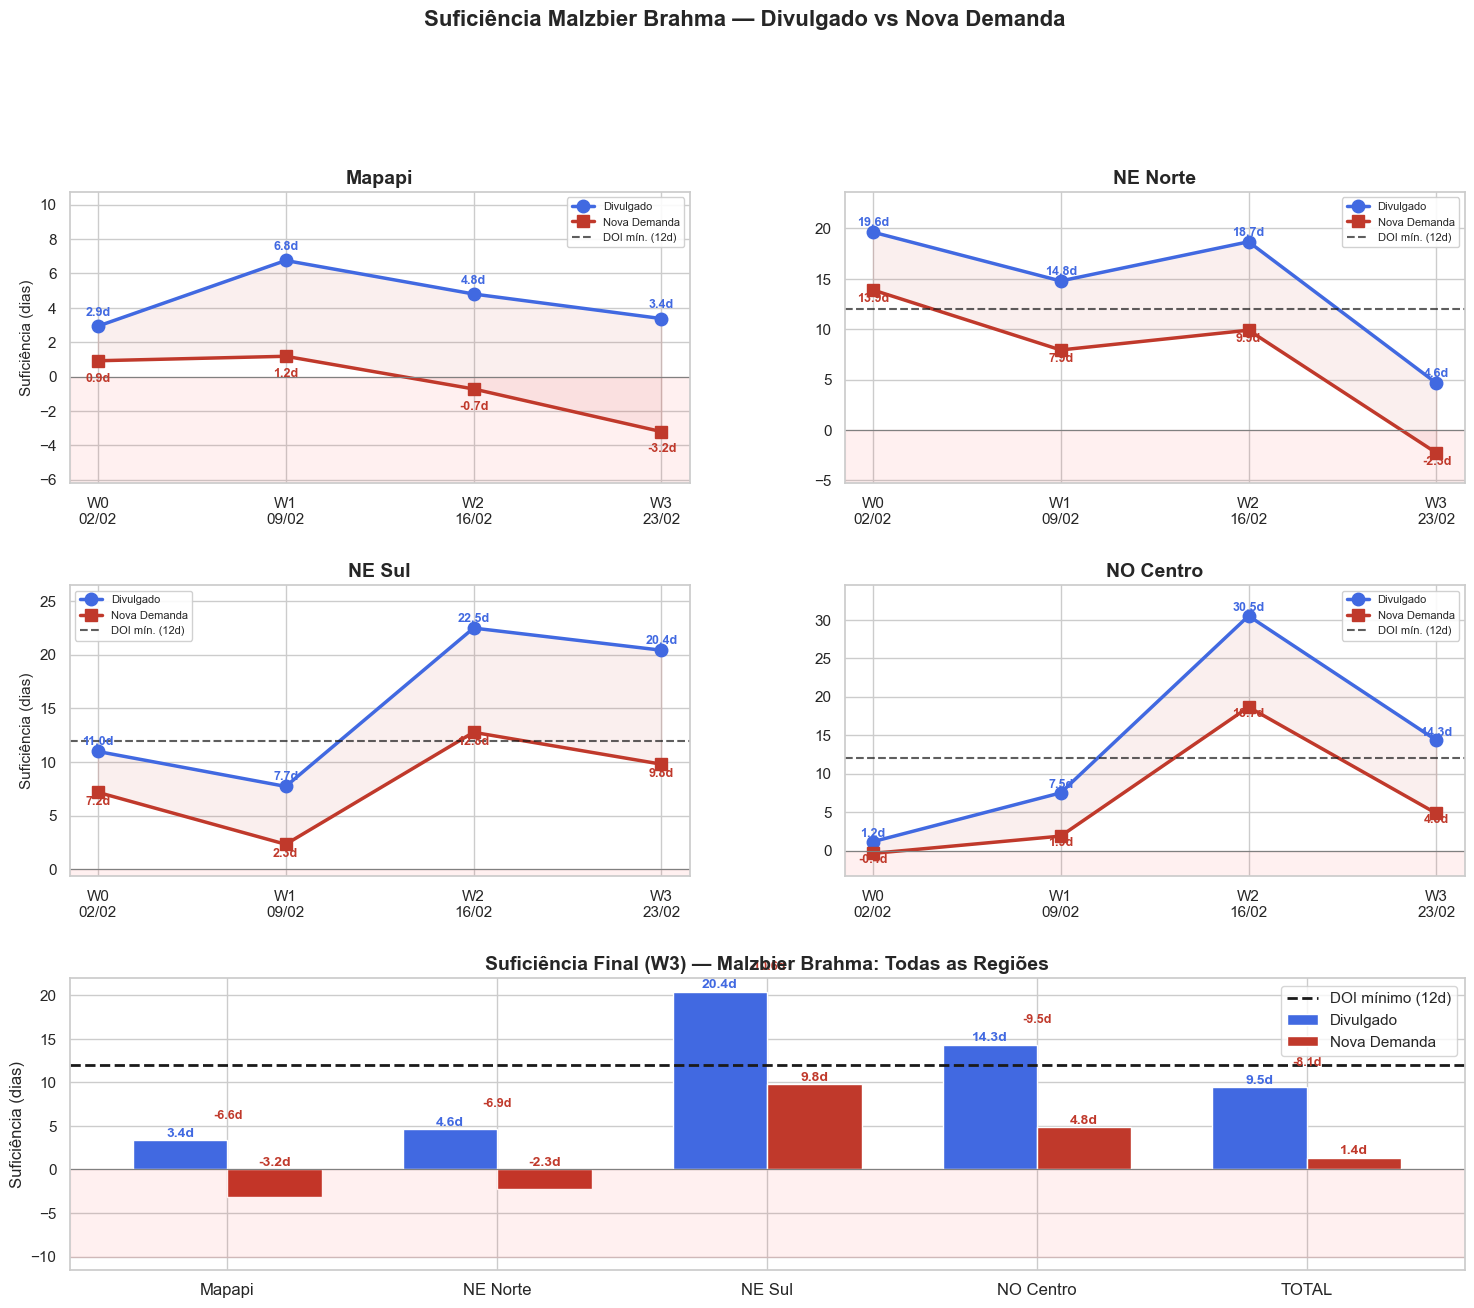

In [430]:
# Suficiência Malzbier — Divulgado vs Nova Demanda, por GEO + consolidado W3
suf_cols = [14, 25, 36, 47]
semanas_label = ['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02']

geo_names = ['Mapapi', 'NE Norte', 'NE Sul', 'NO Centro']
geo_rows  = [20, 21, 22, 24]
total_row = 25

fig = plt.figure(figsize=(18, 14))
# 4 GEOs em grid 2x2 no topo, 1 consolidado embaixo
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1], hspace=0.35, wspace=0.25)

# --- Painéis por GEO (2x2) ---
for idx, (geo, row) in enumerate(zip(geo_names, geo_rows)):
    ax = fig.add_subplot(gs[idx // 2, idx % 2])

    suf_div  = [cenario_div.iloc[row, c] for c in suf_cols]
    suf_novo = [cenario_novo.iloc[row, c] for c in suf_cols]

    ax.plot(semanas_label, suf_div,  'o-', linewidth=2.5, markersize=9, color=AMBEV_BLUE,
            label='Divulgado')
    ax.plot(semanas_label, suf_novo, 's-', linewidth=2.5, markersize=9, color=AMBEV_RED,
            label='Nova Demanda')

    # Fill entre curvas
    ax.fill_between(range(4), suf_div, suf_novo, alpha=0.08,
                    color=AMBEV_RED if suf_novo[0] < suf_div[0] else AMBEV_BLUE)

    # Labels
    for i in range(4):
        ax.text(i, suf_div[i] + 0.6, f'{suf_div[i]:.1f}d', ha='center', fontsize=9,
                color=AMBEV_BLUE, fontweight='bold')
        offset = -1.2 if suf_novo[i] < suf_div[i] else 0.6
        ax.text(i, suf_novo[i] + offset, f'{suf_novo[i]:.1f}d', ha='center', fontsize=9,
                color=AMBEV_RED, fontweight='bold')

    ax.axhline(y=12, color=AMBEV_DARK, linestyle='--', linewidth=1.5, alpha=0.7, label='DOI mín. (12d)')
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
    ax.axhspan(-10, 0, alpha=0.06, color='red')

    ax.set_title(geo, fontsize=14, fontweight='bold')
    ax.set_ylim(min(min(suf_div), min(suf_novo)) - 3, max(max(suf_div), max(suf_novo)) + 4)
    if idx % 2 == 0:
        ax.set_ylabel('Suficiência (dias)', fontsize=11)
    ax.legend(loc='best', fontsize=8, framealpha=0.9)

# --- Painel consolidado W3 (embaixo, ocupando as 2 colunas) ---
ax_bottom = fig.add_subplot(gs[2, :])

all_geos = geo_names + ['TOTAL']
all_rows = geo_rows + [total_row]

suf_div_w3  = [cenario_div.iloc[r, 47] for r in all_rows]
suf_novo_w3 = [cenario_novo.iloc[r, 47] for r in all_rows]

x = np.arange(len(all_geos))
w = 0.35

bars1 = ax_bottom.bar(x - w/2, suf_div_w3,  w, label='Divulgado',    color=AMBEV_BLUE, edgecolor='white')
bars2 = ax_bottom.bar(x + w/2, suf_novo_w3, w, label='Nova Demanda', color=AMBEV_RED,  edgecolor='white')

ax_bottom.axhline(y=12, color=AMBEV_DARK, linestyle='--', linewidth=2, label='DOI mínimo (12d)')
ax_bottom.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
ax_bottom.axhspan(-10, 0, alpha=0.06, color='red')

for i in range(len(all_geos)):
    ax_bottom.text(i - w/2, max(suf_div_w3[i], 0) + 0.4, f'{suf_div_w3[i]:.1f}d',
                   ha='center', fontsize=10, fontweight='bold', color=AMBEV_BLUE)
    color_txt = AMBEV_RED
    y_pos = max(suf_novo_w3[i], 0) + 0.4
    ax_bottom.text(i + w/2, y_pos, f'{suf_novo_w3[i]:.1f}d',
                   ha='center', fontsize=10, fontweight='bold', color=color_txt)

    # Delta
    delta = suf_novo_w3[i] - suf_div_w3[i]
    sign = '+' if delta >= 0 else ''
    mid_y = max(max(suf_div_w3[i], suf_novo_w3[i]) + 2.5, 2)
    ax_bottom.text(i, mid_y, f'{sign}{delta:.1f}d', ha='center', fontsize=9,
                   fontweight='bold', color=AMBEV_GREEN if delta >= 0 else AMBEV_RED)

ax_bottom.set_xticks(x)
ax_bottom.set_xticklabels(all_geos, fontsize=12)
ax_bottom.set_ylabel('Suficiência (dias)', fontsize=12)
ax_bottom.set_title('Suficiência Final (W3) — Malzbier Brahma: Todas as Regiões',
                     fontsize=14, fontweight='bold')
ax_bottom.legend(fontsize=11, loc='upper right')

fig.suptitle('Suficiência Malzbier Brahma — Divulgado vs Nova Demanda',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 13. Evolução da Demanda por Cerveja — Cenário com Nova Demanda
Demanda total NENO (HL) de cada cerveja nas 4 semanas de fevereiro/2026, extraída diretamente da aba "Cenário com Nova Demanda".

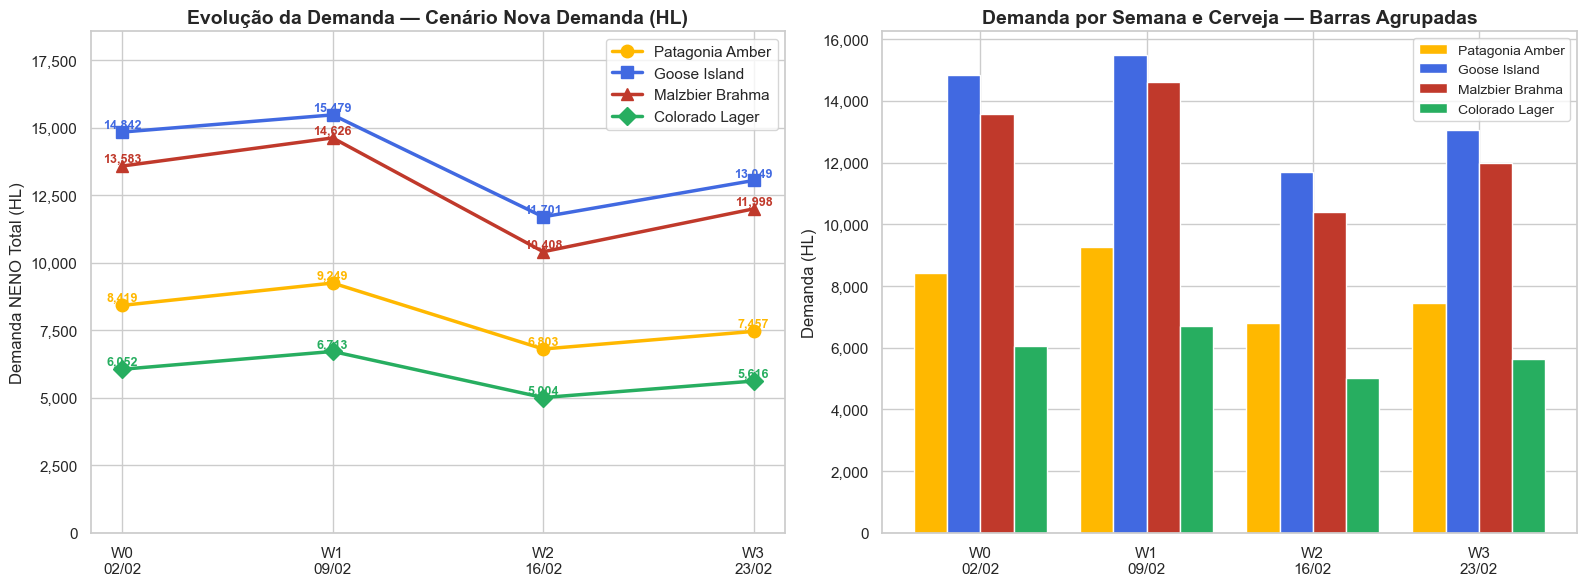

In [431]:
# Evolução da demanda das 4 cervejas — Cenário com Nova Demanda
semanas = ['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02']
dem_cols = [3, 16, 27, 38]  # Coluna Demanda de cada semana

cervejas = {
    'Patagonia Amber':  [cenario_novo.iloc[9,  c] for c in dem_cols],
    'Goose Island':     [cenario_novo.iloc[17, c] for c in dem_cols],
    'Malzbier Brahma':  [cenario_novo.iloc[25, c] for c in dem_cols],
    'Colorado Lager':   [cenario_novo.iloc[33, c] for c in dem_cols],
}

cores = {
    'Patagonia Amber': AMBEV_YELLOW,
    'Goose Island':    AMBEV_BLUE,
    'Malzbier Brahma': AMBEV_RED,
    'Colorado Lager':  AMBEV_GREEN,
}

markers = {'Patagonia Amber': 'o', 'Goose Island': 's', 'Malzbier Brahma': '^', 'Colorado Lager': 'D'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico de linhas ---
ax = axes[0]
for nome, demanda in cervejas.items():
    ax.plot(semanas, demanda, marker=markers[nome], linewidth=2.5, markersize=9,
            label=nome, color=cores[nome])
    for i, v in enumerate(demanda):
        ax.text(i, v + 150, f'{v:,.0f}', ha='center', fontsize=9,
                color=cores[nome], fontweight='bold')

ax.set_title('Evolução da Demanda — Cenário Nova Demanda (HL)', fontsize=14, fontweight='bold')
ax.set_ylabel('Demanda NENO Total (HL)')
ax.set_ylim(0, max(max(v) for v in cervejas.values()) * 1.2)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# --- Gráfico de barras agrupadas ---
ax2 = axes[1]
x = np.arange(len(semanas))
w = 0.2
for i, (nome, demanda) in enumerate(cervejas.items()):
    ax2.bar(x + i*w - 0.3, demanda, w, label=nome, color=cores[nome], edgecolor='white')

ax2.set_title('Demanda por Semana e Cerveja — Barras Agrupadas', fontsize=14, fontweight='bold')
ax2.set_ylabel('Demanda (HL)')
ax2.set_xticks(x)
ax2.set_xticklabels(semanas)
ax2.legend(fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

## 14. Gap Produção Local (WSNP) vs Demanda — Cenário Nova Demanda
Comparação entre a produção local programada (PCP) e a demanda NENO por cerveja. O déficit indica a necessidade de transferências de SP para suprir o volume.

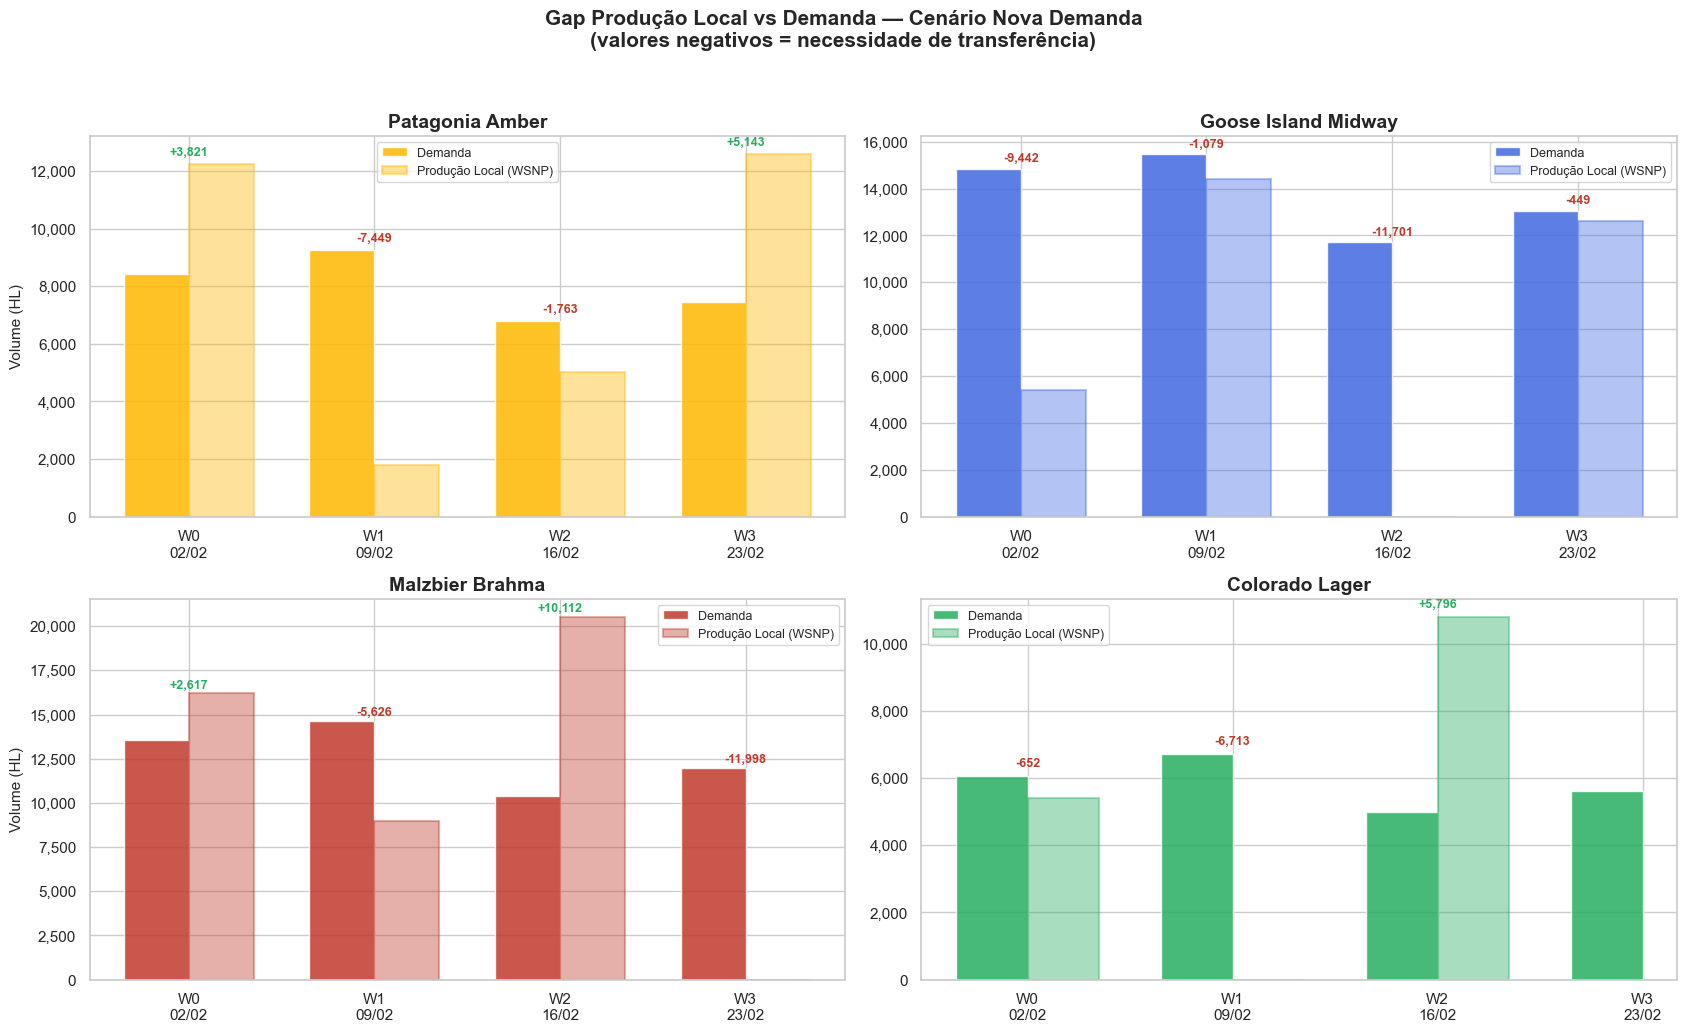

In [432]:
# Gap Produção Local vs Demanda — 4 cervejas, Cenário Nova Demanda
semanas_label = ['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02']
dem_cols = [3, 16, 27, 38]
wsnp_cols = [5, 18, 29, 40]

cervejas_gap = {
    'Patagonia Amber':     {'total': 9,  'color': AMBEV_YELLOW},
    'Goose Island Midway': {'total': 17, 'color': AMBEV_BLUE},
    'Malzbier Brahma':     {'total': 25, 'color': AMBEV_RED},
    'Colorado Lager':      {'total': 33, 'color': AMBEV_GREEN},
}

fig, axes = plt.subplots(2, 2, figsize=(17, 10))
axes_flat = axes.flatten()
x = np.arange(4)
w = 0.35

for idx, (cerveja, cfg) in enumerate(cervejas_gap.items()):
    ax = axes_flat[idx]
    row = cfg['total']

    demanda = [cenario_novo.iloc[row, c] for c in dem_cols]
    wsnp = [cenario_novo.iloc[row, c] for c in wsnp_cols]
    # Substituir placeholders 99
    wsnp = [np.nan if v == 99 else max(v, 0) for v in wsnp]
    demanda_clean = [d for d, w_ in zip(demanda, wsnp) if not np.isnan(w_)]
    wsnp_clean = [w_ for w_ in wsnp if not np.isnan(w_)]

    ax.bar(x - w/2, demanda, w, label='Demanda', color=cfg['color'], alpha=0.85, edgecolor='white')
    ax.bar(x + w/2, wsnp, w, label='Produção Local (WSNP)', color=cfg['color'], alpha=0.4,
           edgecolor=cfg['color'], linewidth=1.5)

    # Gap (déficit)
    for i in range(4):
        if not np.isnan(wsnp[i]):
            gap = wsnp[i] - demanda[i]
            color_gap = AMBEV_GREEN if gap >= 0 else AMBEV_RED
            y_pos = max(demanda[i], wsnp[i]) + 300
            sign = '+' if gap >= 0 else ''
            ax.text(i, y_pos, f'{sign}{gap:,.0f}', ha='center', fontsize=9,
                    fontweight='bold', color=color_gap)

    ax.set_xticks(x); ax.set_xticklabels(semanas_label)
    ax.set_title(cerveja, fontsize=14, fontweight='bold')
    if idx % 2 == 0:
        ax.set_ylabel('Volume (HL)', fontsize=11)
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

fig.suptitle('Gap Produção Local vs Demanda — Cenário Nova Demanda\n(valores negativos = necessidade de transferência)',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## 15. Impacto do +30% Malzbier na Demanda Total NENO
Comparação da demanda total NENO entre Cenário Divulgado e Nova Demanda. Apenas Malzbier Brahma sofre alteração (+30%); as demais cervejas permanecem iguais.

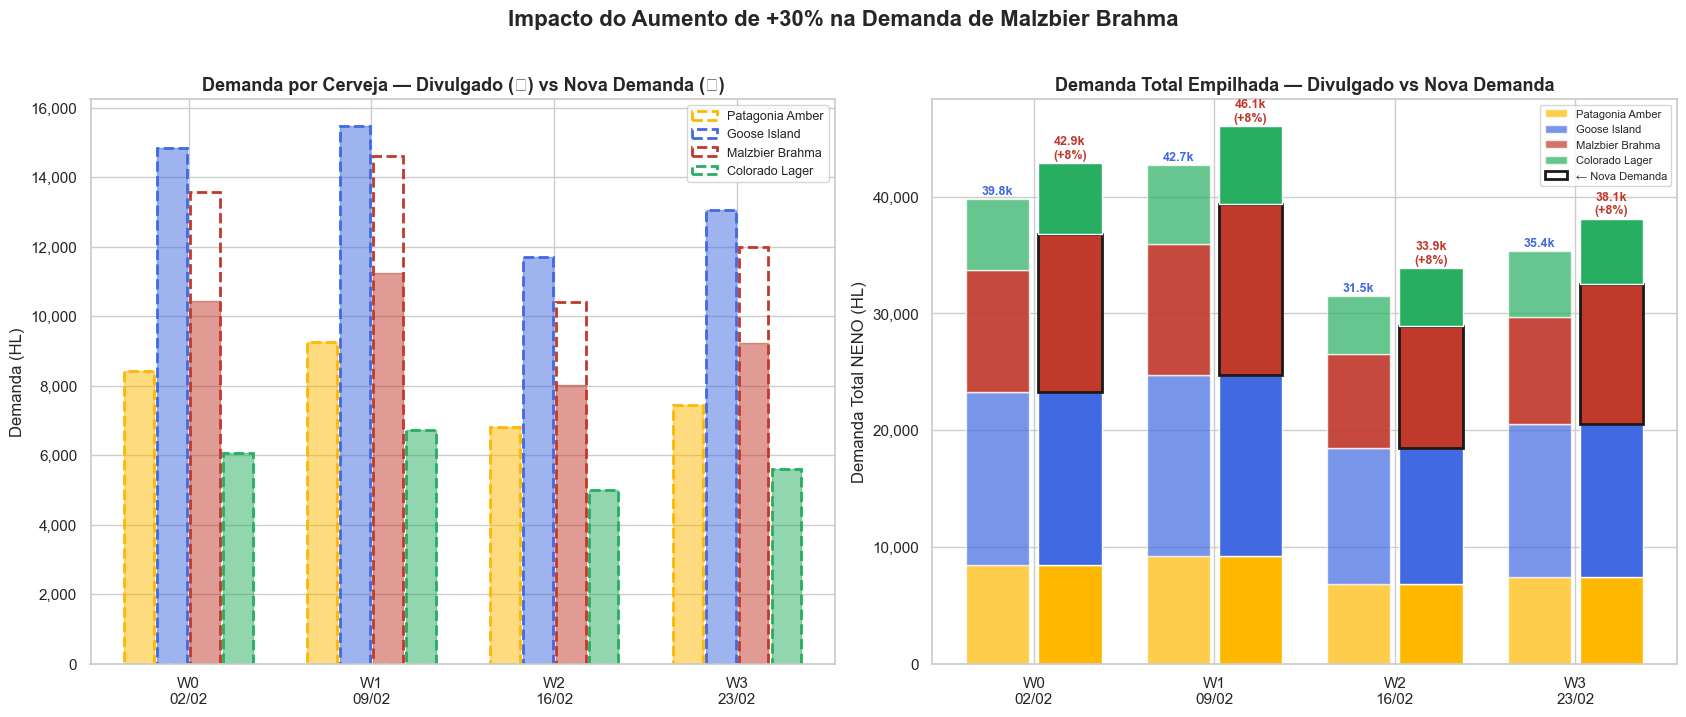

In [433]:
# Impacto do +30% Malzbier na Demanda Total NENO
dem_cols = [3, 16, 27, 38]
semanas_label = ['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02']

cervejas_total = {
    'Patagonia Amber': 9,
    'Goose Island':    17,
    'Malzbier Brahma': 25,
    'Colorado Lager':  33,
}
beer_colors = [AMBEV_YELLOW, AMBEV_BLUE, AMBEV_RED, AMBEV_GREEN]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 7))
x = np.arange(4)
w = 0.18

# --- Demanda por cerveja (barras agrupadas, ambos cenários) ---
for i, (beer, row) in enumerate(cervejas_total.items()):
    dem_div  = [cenario_div.iloc[row, c] for c in dem_cols]
    dem_novo = [cenario_novo.iloc[row, c] for c in dem_cols]

    # Barras Divulgado (preenchidas) e Nova Demanda (hachuradas)
    ax1.bar(x + i*w - 0.27, dem_div,  w*0.9, color=beer_colors[i], alpha=0.5,
            edgecolor=beer_colors[i], linewidth=1)
    ax1.bar(x + i*w - 0.27, dem_novo, w*0.9, color='none',
            edgecolor=beer_colors[i], linewidth=2, linestyle='--', label=beer)

ax1.set_xticks(x); ax1.set_xticklabels(semanas_label)
ax1.set_ylabel('Demanda (HL)')
ax1.set_title('Demanda por Cerveja — Divulgado (▮) vs Nova Demanda (┅)',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# --- Demanda total NENO empilhada ---
bottom_div = np.zeros(4)
bottom_novo = np.zeros(4)
for i, (beer, row) in enumerate(cervejas_total.items()):
    dem_div  = [cenario_div.iloc[row, c] for c in dem_cols]
    dem_novo = [cenario_novo.iloc[row, c] for c in dem_cols]

    ax2.bar(x - 0.2, dem_div,  0.35, bottom=bottom_div,  color=beer_colors[i],
            alpha=0.7, edgecolor='white', label=beer if i == 0 else '')
    ax2.bar(x + 0.2, dem_novo, 0.35, bottom=bottom_novo, color=beer_colors[i],
            edgecolor='white')

    # Destacar Malzbier no empilhado
    if beer == 'Malzbier Brahma':
        ax2.bar(x - 0.2, dem_div,  0.35, bottom=bottom_div,  color=beer_colors[i],
                alpha=0.7, edgecolor='white', label='Divulgado')
        ax2.bar(x + 0.2, dem_novo, 0.35, bottom=bottom_novo, color=beer_colors[i],
                edgecolor=AMBEV_DARK, linewidth=2, label='Nova Demanda')

    bottom_div  += np.array(dem_div)
    bottom_novo += np.array(dem_novo)

# Total labels
for i in range(4):
    delta = bottom_novo[i] - bottom_div[i]
    pct = delta / bottom_div[i] * 100
    ax2.text(-0.2 + i, bottom_div[i] + 400, f'{bottom_div[i]/1000:.1f}k',
             ha='center', fontsize=9, fontweight='bold', color=AMBEV_BLUE)
    ax2.text(0.2 + i, bottom_novo[i] + 400, f'{bottom_novo[i]/1000:.1f}k\n(+{pct:.0f}%)',
             ha='center', fontsize=9, fontweight='bold', color=AMBEV_RED)

ax2.set_xticks(x); ax2.set_xticklabels(semanas_label)
ax2.set_ylabel('Demanda Total NENO (HL)')
ax2.set_title('Demanda Total Empilhada — Divulgado vs Nova Demanda',
              fontsize=13, fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Legenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, alpha=0.7, label=b)
                   for b, c in zip(cervejas_total.keys(), beer_colors)]
legend_elements.append(Patch(facecolor='white', edgecolor=AMBEV_DARK, linewidth=2,
                             label='← Nova Demanda'))
ax2.legend(handles=legend_elements, fontsize=8, loc='upper right')

fig.suptitle('Impacto do Aumento de +30% na Demanda de Malzbier Brahma',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 16. Estimativa de Custo de Transferência SP → NE
Custo estimado das transferências externas (cabotagem) por cerveja, calculado a partir dos volumes transferidos e das tarifas R$/HL da aba de custos.

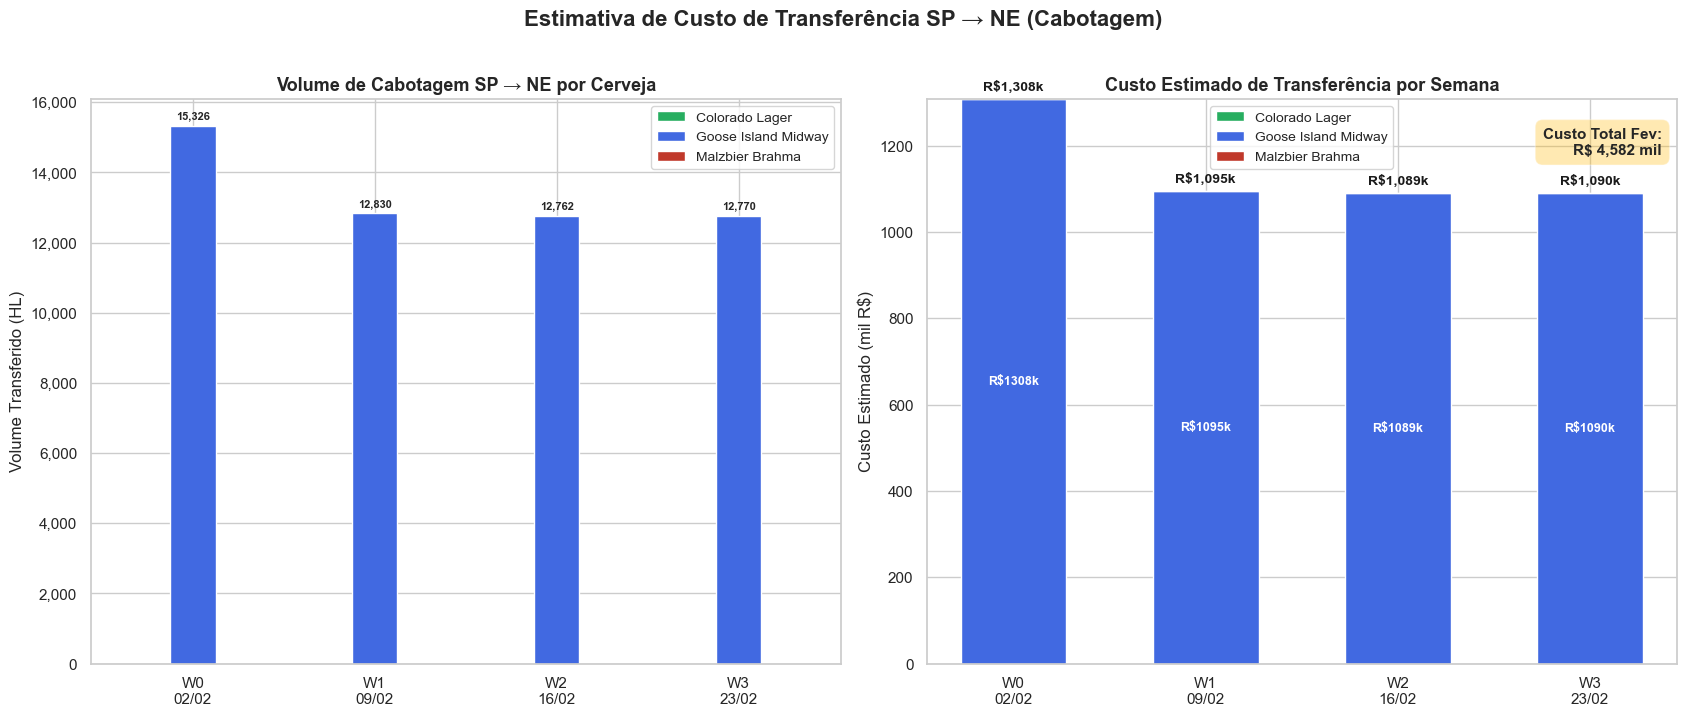

In [434]:
# Estimativa de Custo de Transferência SP → NE (Cabotagem)
semanas_label = ['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02']
cabo_cols = [10, 21, 32, 43]

# Custos unitários médios (R$/HL) — média Camaçari/Fonte Mata
custo_colorado = (custos.iloc[3, 4] + custos.iloc[4, 4]) / 2   # ~79 R$/HL
custo_goose    = (custos.iloc[5, 4] + custos.iloc[7, 4]) / 2   # ~85 R$/HL
custo_malzbier = (custos.iloc[6, 4] + custos.iloc[8, 4]) / 2   # ~90 R$/HL

# Volumes de cabotagem por cerveja (Nova Demanda, TOTAL row)
transfer_config = {
    'Colorado Lager':      {'total': 33, 'custo': custo_colorado, 'color': AMBEV_GREEN},
    'Goose Island Midway': {'total': 17, 'custo': custo_goose,    'color': AMBEV_BLUE},
    'Malzbier Brahma':     {'total': 25, 'custo': custo_malzbier, 'color': AMBEV_RED},
}

# Patagonia: usar mesmos cols mas com cenario_novo row 9
pat_cabo = [cenario_novo.iloc[9, c] for c in cabo_cols]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 7))
x = np.arange(4)
w = 0.25

total_custo_semana = np.zeros(4)
custo_por_beer = {}

for i, (beer, cfg) in enumerate(transfer_config.items()):
    vols_raw = [cenario_novo.iloc[cfg['total'], c] for c in cabo_cols]
    # Tratar 99 como 0, negativos como 0
    vols = [max(v, 0) if v != 99 else 0 for v in vols_raw]
    custos_semana = [v * cfg['custo'] for v in vols]
    custo_por_beer[beer] = custos_semana

    ax1.bar(x + i*w - 0.25, vols, w, label=beer, color=cfg['color'], edgecolor='white')
    for j in range(4):
        if vols[j] > 0:
            ax1.text(j + i*w - 0.25, vols[j] + 200, f'{vols[j]:,.0f}',
                     ha='center', fontsize=8, fontweight='bold')

    total_custo_semana += np.array(custos_semana)

ax1.set_xticks(x); ax1.set_xticklabels(semanas_label)
ax1.set_ylabel('Volume Transferido (HL)')
ax1.set_title('Volume de Cabotagem SP → NE por Cerveja', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# --- Custo empilhado (direita) ---
bottom = np.zeros(4)
beer_list = list(transfer_config.keys())
colors = [cfg['color'] for cfg in transfer_config.values()]

for i, beer in enumerate(beer_list):
    vals = [c / 1000 for c in custo_por_beer[beer]]  # em mil R$
    ax2.bar(x, vals, 0.55, bottom=bottom, label=beer, color=colors[i], edgecolor='white')
    for j in range(4):
        if vals[j] > 5:
            ax2.text(j, bottom[j] + vals[j]/2, f'R${vals[j]:.0f}k',
                     ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    bottom += np.array(vals)

# Total no topo
for j in range(4):
    ax2.text(j, bottom[j] + 20, f'R${bottom[j]:,.0f}k',
             ha='center', fontsize=10, fontweight='bold', color=AMBEV_DARK)

# Total geral acumulado
total_geral = sum(sum(v) for v in custo_por_beer.values())
ax2.text(0.98, 0.95, f'Custo Total Fev:\nR$ {total_geral/1000:,.0f} mil',
         transform=ax2.transAxes, fontsize=11, fontweight='bold', ha='right', va='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor=AMBEV_YELLOW, alpha=0.3))

ax2.set_xticks(x); ax2.set_xticklabels(semanas_label)
ax2.set_ylabel('Custo Estimado (mil R$)')
ax2.set_title('Custo Estimado de Transferência por Semana', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)

fig.suptitle('Estimativa de Custo de Transferência SP → NE (Cabotagem)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 17. Mapa de Risco de Ruptura — Suficiência por Cerveja e GEO
Heatmap identificando quais combinações cerveja × GEO × semana estão abaixo do DOI mínimo de 12 dias no Cenário Nova Demanda. Valores negativos indicam ruptura de estoque.

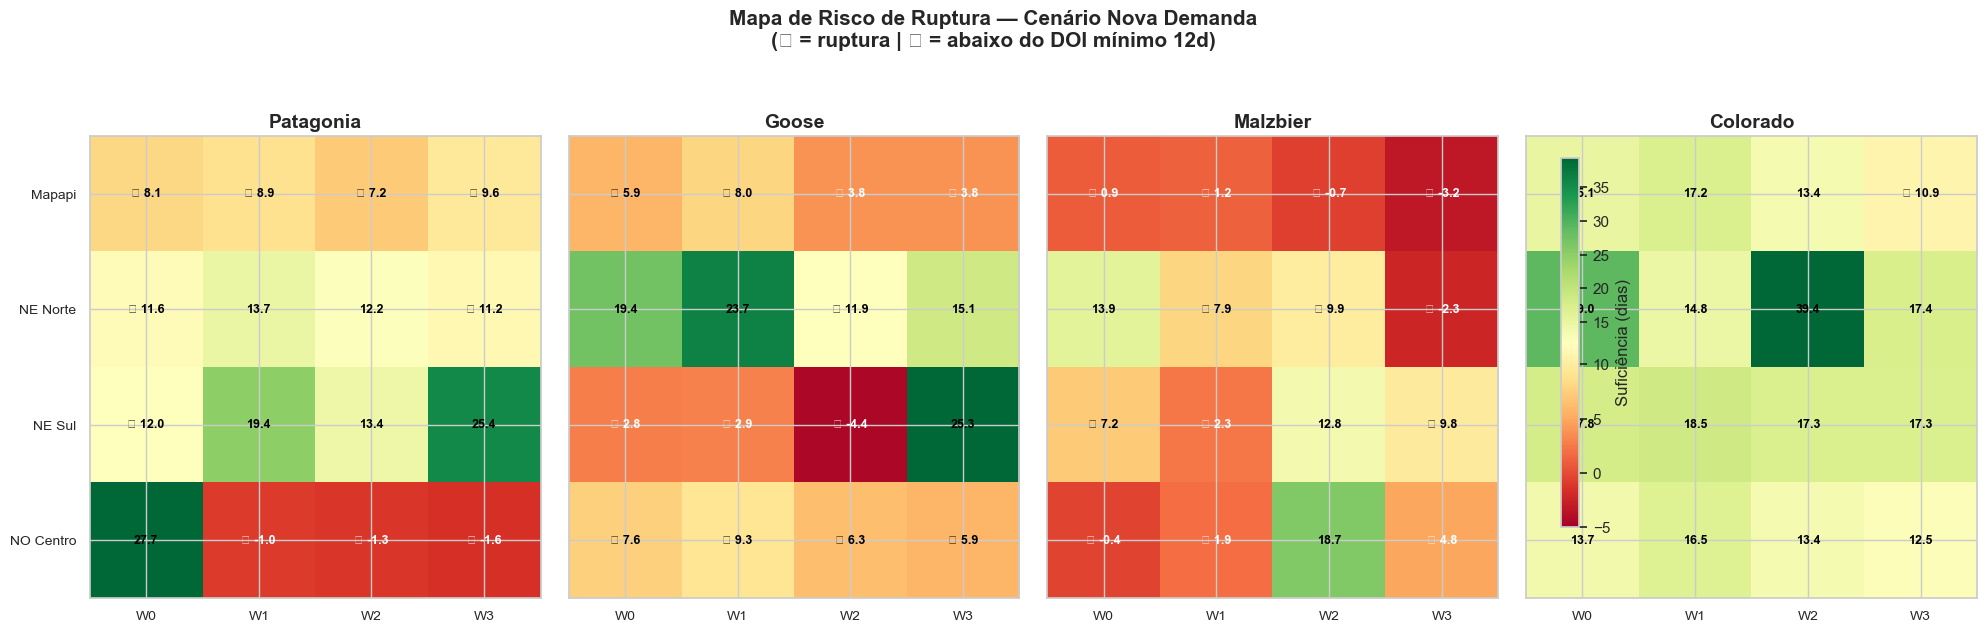

In [435]:
# Heatmap de Risco — Suficiência por Cerveja × GEO × Semana (Nova Demanda)
from matplotlib.colors import TwoSlopeNorm

suf_cols = [14, 25, 36, 47]
geo_names = ['Mapapi', 'NE Norte', 'NE Sul', 'NO Centro']

cervejas_hm = {
    'Patagonia':  [4, 5, 6, 8],
    'Goose':      [12, 13, 14, 16],
    'Malzbier':   [20, 21, 22, 24],
    'Colorado':   [28, 29, 30, 32],
}

fig, axes = plt.subplots(1, 4, figsize=(20, 6), sharey=True)

for idx, (cerveja, geo_rows) in enumerate(cervejas_hm.items()):
    ax = axes[idx]

    # Montar matriz 4 GEOs × 4 semanas
    data = np.zeros((4, 4))
    for g, row in enumerate(geo_rows):
        for w, col in enumerate(suf_cols):
            v = cenario_novo.iloc[row, col]
            data[g, w] = v if v != 99 else np.nan

    # Colormap: vermelho (negativo/ruptura) → amarelo (< 12) → verde (> 12)
    vmin = min(np.nanmin(data), -5)
    vmax = max(np.nanmax(data), 25)
    norm = TwoSlopeNorm(vmin=vmin, vcenter=12, vmax=vmax)

    im = ax.imshow(data, cmap='RdYlGn', norm=norm, aspect='auto')

    ax.set_xticks(range(4))
    ax.set_xticklabels(['W0', 'W1', 'W2', 'W3'], fontsize=10)
    if idx == 0:
        ax.set_yticks(range(4))
        ax.set_yticklabels(geo_names, fontsize=10)
    ax.set_title(cerveja, fontsize=14, fontweight='bold')

    # Valores e ícones de alerta
    for g in range(4):
        for w in range(4):
            v = data[g, w]
            if np.isnan(v):
                ax.text(w, g, 'N/A', ha='center', va='center', fontsize=9, color='gray')
            else:
                color = 'white' if v < 5 else 'black'
                icon = '⚠ ' if v < 0 else ('⚡ ' if v < 12 else '')
                ax.text(w, g, f'{icon}{v:.1f}', ha='center', va='center',
                        fontsize=9, fontweight='bold', color=color)

plt.colorbar(im, ax=axes, shrink=0.8, pad=0.02, label='Suficiência (dias)')

fig.suptitle('Mapa de Risco de Ruptura — Cenário Nova Demanda\n(⚠ = ruptura | ⚡ = abaixo do DOI mínimo 12d)',
             fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 18. Pressão sobre a Capacidade Produtiva — Demanda Total vs Capacidade
Comparação entre a demanda total NENO (4 cervejas) e a capacidade produtiva combinada (AQ541 + NS541). Mostra o déficit que precisa ser suprido via transferências e o agravamento com o aumento de +30% de Malzbier.

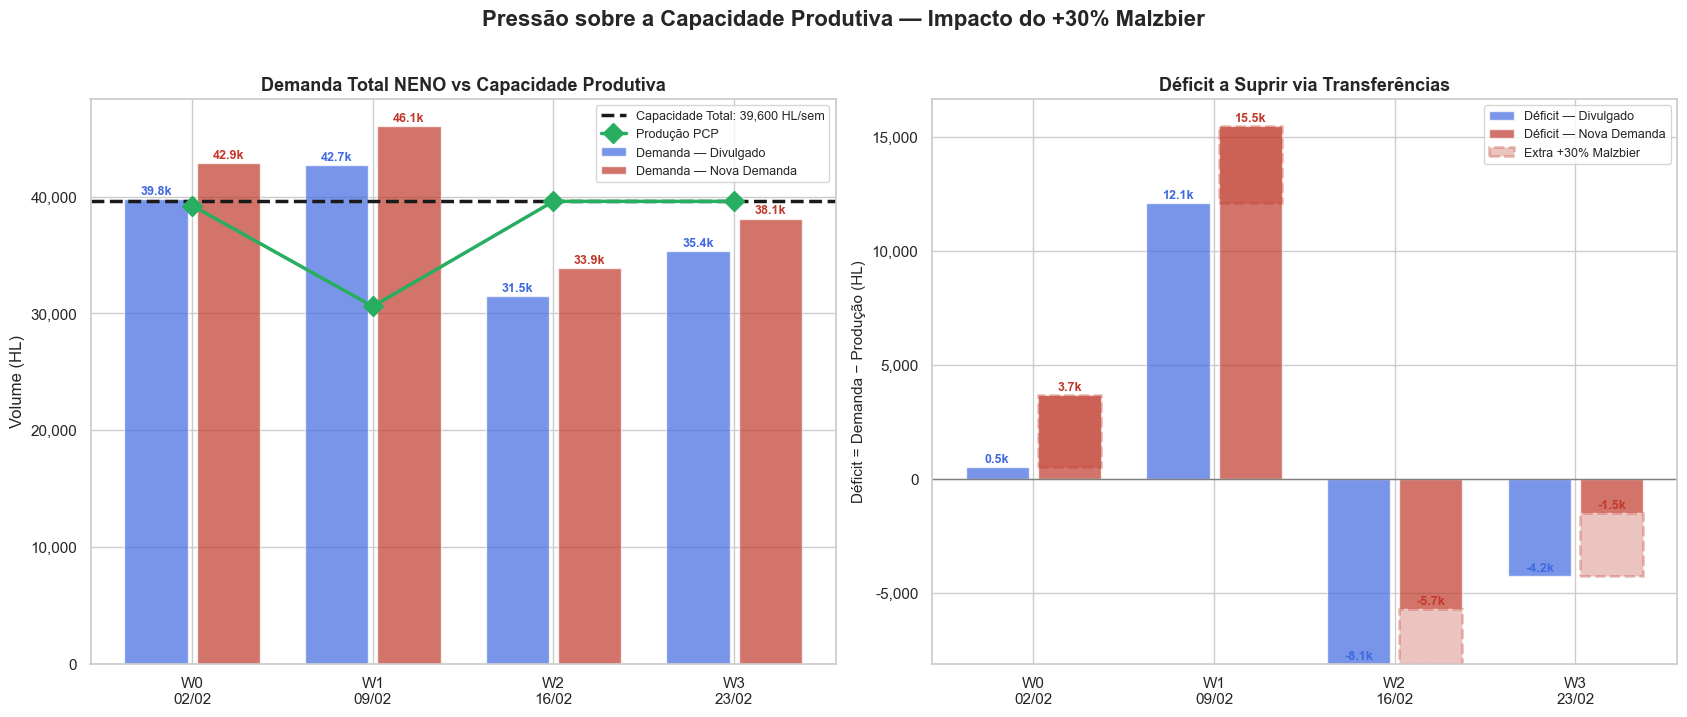

In [436]:
# Pressão sobre Capacidade — Demanda Total NENO vs Capacidade Produtiva
dem_cols = [3, 16, 27, 38]
semanas_label = ['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02']
totais_rows = [9, 17, 25, 33]  # TOTAL de cada cerveja

# Capacidade semanal combinada
cap_aq = producao_pcp.iloc[2, 3]
cap_ns = producao_pcp.iloc[9, 3]
cap_total = cap_aq + cap_ns

# Produção PCP real por semana
prod_total = [producao_pcp.iloc[5, c] + producao_pcp.iloc[15, c] for c in range(6, 10)]

# Demanda total — Divulgado vs Nova Demanda
dem_div_total = np.zeros(4)
dem_novo_total = np.zeros(4)
for row in totais_rows:
    for i, c in enumerate(dem_cols):
        dem_div_total[i]  += cenario_div.iloc[row, c]
        dem_novo_total[i] += cenario_novo.iloc[row, c]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 7))
x = np.arange(4)

# --- Esquerda: Demanda vs Capacidade vs Produção ---
ax1.bar(x - 0.2, dem_div_total,  0.35, label='Demanda — Divulgado', color=AMBEV_BLUE, alpha=0.7)
ax1.bar(x + 0.2, dem_novo_total, 0.35, label='Demanda — Nova Demanda', color=AMBEV_RED, alpha=0.7)
ax1.axhline(y=cap_total, color=AMBEV_DARK, linestyle='--', linewidth=2.5,
            label=f'Capacidade Total: {cap_total:,.0f} HL/sem')
ax1.plot(x, prod_total, 'D-', color=AMBEV_GREEN, linewidth=2.5, markersize=10,
         label='Produção PCP')

# Labels
for i in range(4):
    ax1.text(i - 0.2, dem_div_total[i] + 400, f'{dem_div_total[i]/1000:.1f}k',
             ha='center', fontsize=9, color=AMBEV_BLUE, fontweight='bold')
    ax1.text(i + 0.2, dem_novo_total[i] + 400, f'{dem_novo_total[i]/1000:.1f}k',
             ha='center', fontsize=9, color=AMBEV_RED, fontweight='bold')

ax1.set_xticks(x); ax1.set_xticklabels(semanas_label)
ax1.set_ylabel('Volume (HL)', fontsize=12)
ax1.set_title('Demanda Total NENO vs Capacidade Produtiva', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, loc='upper right')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# --- Direita: Déficit (gap) que precisa de transferência ---
gap_div  = [dem_div_total[i] - prod_total[i] for i in range(4)]
gap_novo = [dem_novo_total[i] - prod_total[i] for i in range(4)]
gap_malz_extra = [dem_novo_total[i] - dem_div_total[i] for i in range(4)]

ax2.bar(x - 0.2, gap_div,  0.35, label='Déficit — Divulgado', color=AMBEV_BLUE, alpha=0.7)
ax2.bar(x + 0.2, gap_novo, 0.35, label='Déficit — Nova Demanda', color=AMBEV_RED, alpha=0.7)

# Destacar parcela extra do Malzbier +30%
ax2.bar(x + 0.2, gap_malz_extra, 0.35, bottom=[g - m for g, m in zip(gap_novo, gap_malz_extra)],
        color=AMBEV_RED, alpha=0.3, edgecolor=AMBEV_RED, linewidth=2, linestyle='--',
        label='Extra +30% Malzbier')

ax2.axhline(y=0, color='gray', linestyle='-', linewidth=1)

for i in range(4):
    ax2.text(i - 0.2, gap_div[i] + 200, f'{gap_div[i]/1000:.1f}k',
             ha='center', fontsize=9, color=AMBEV_BLUE, fontweight='bold')
    ax2.text(i + 0.2, gap_novo[i] + 200, f'{gap_novo[i]/1000:.1f}k',
             ha='center', fontsize=9, color=AMBEV_RED, fontweight='bold')

ax2.set_xticks(x); ax2.set_xticklabels(semanas_label)
ax2.set_ylabel('Déficit = Demanda − Produção (HL)', fontsize=11)
ax2.set_title('Déficit a Suprir via Transferências', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

fig.suptitle('Pressão sobre a Capacidade Produtiva — Impacto do +30% Malzbier',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()